<a href="https://colab.research.google.com/github/drfperez/openair/blob/main/Dim_figuras_2_ok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- PARTE 1: DESDE SERVIDORES HASTA BD CONJUNTA ---


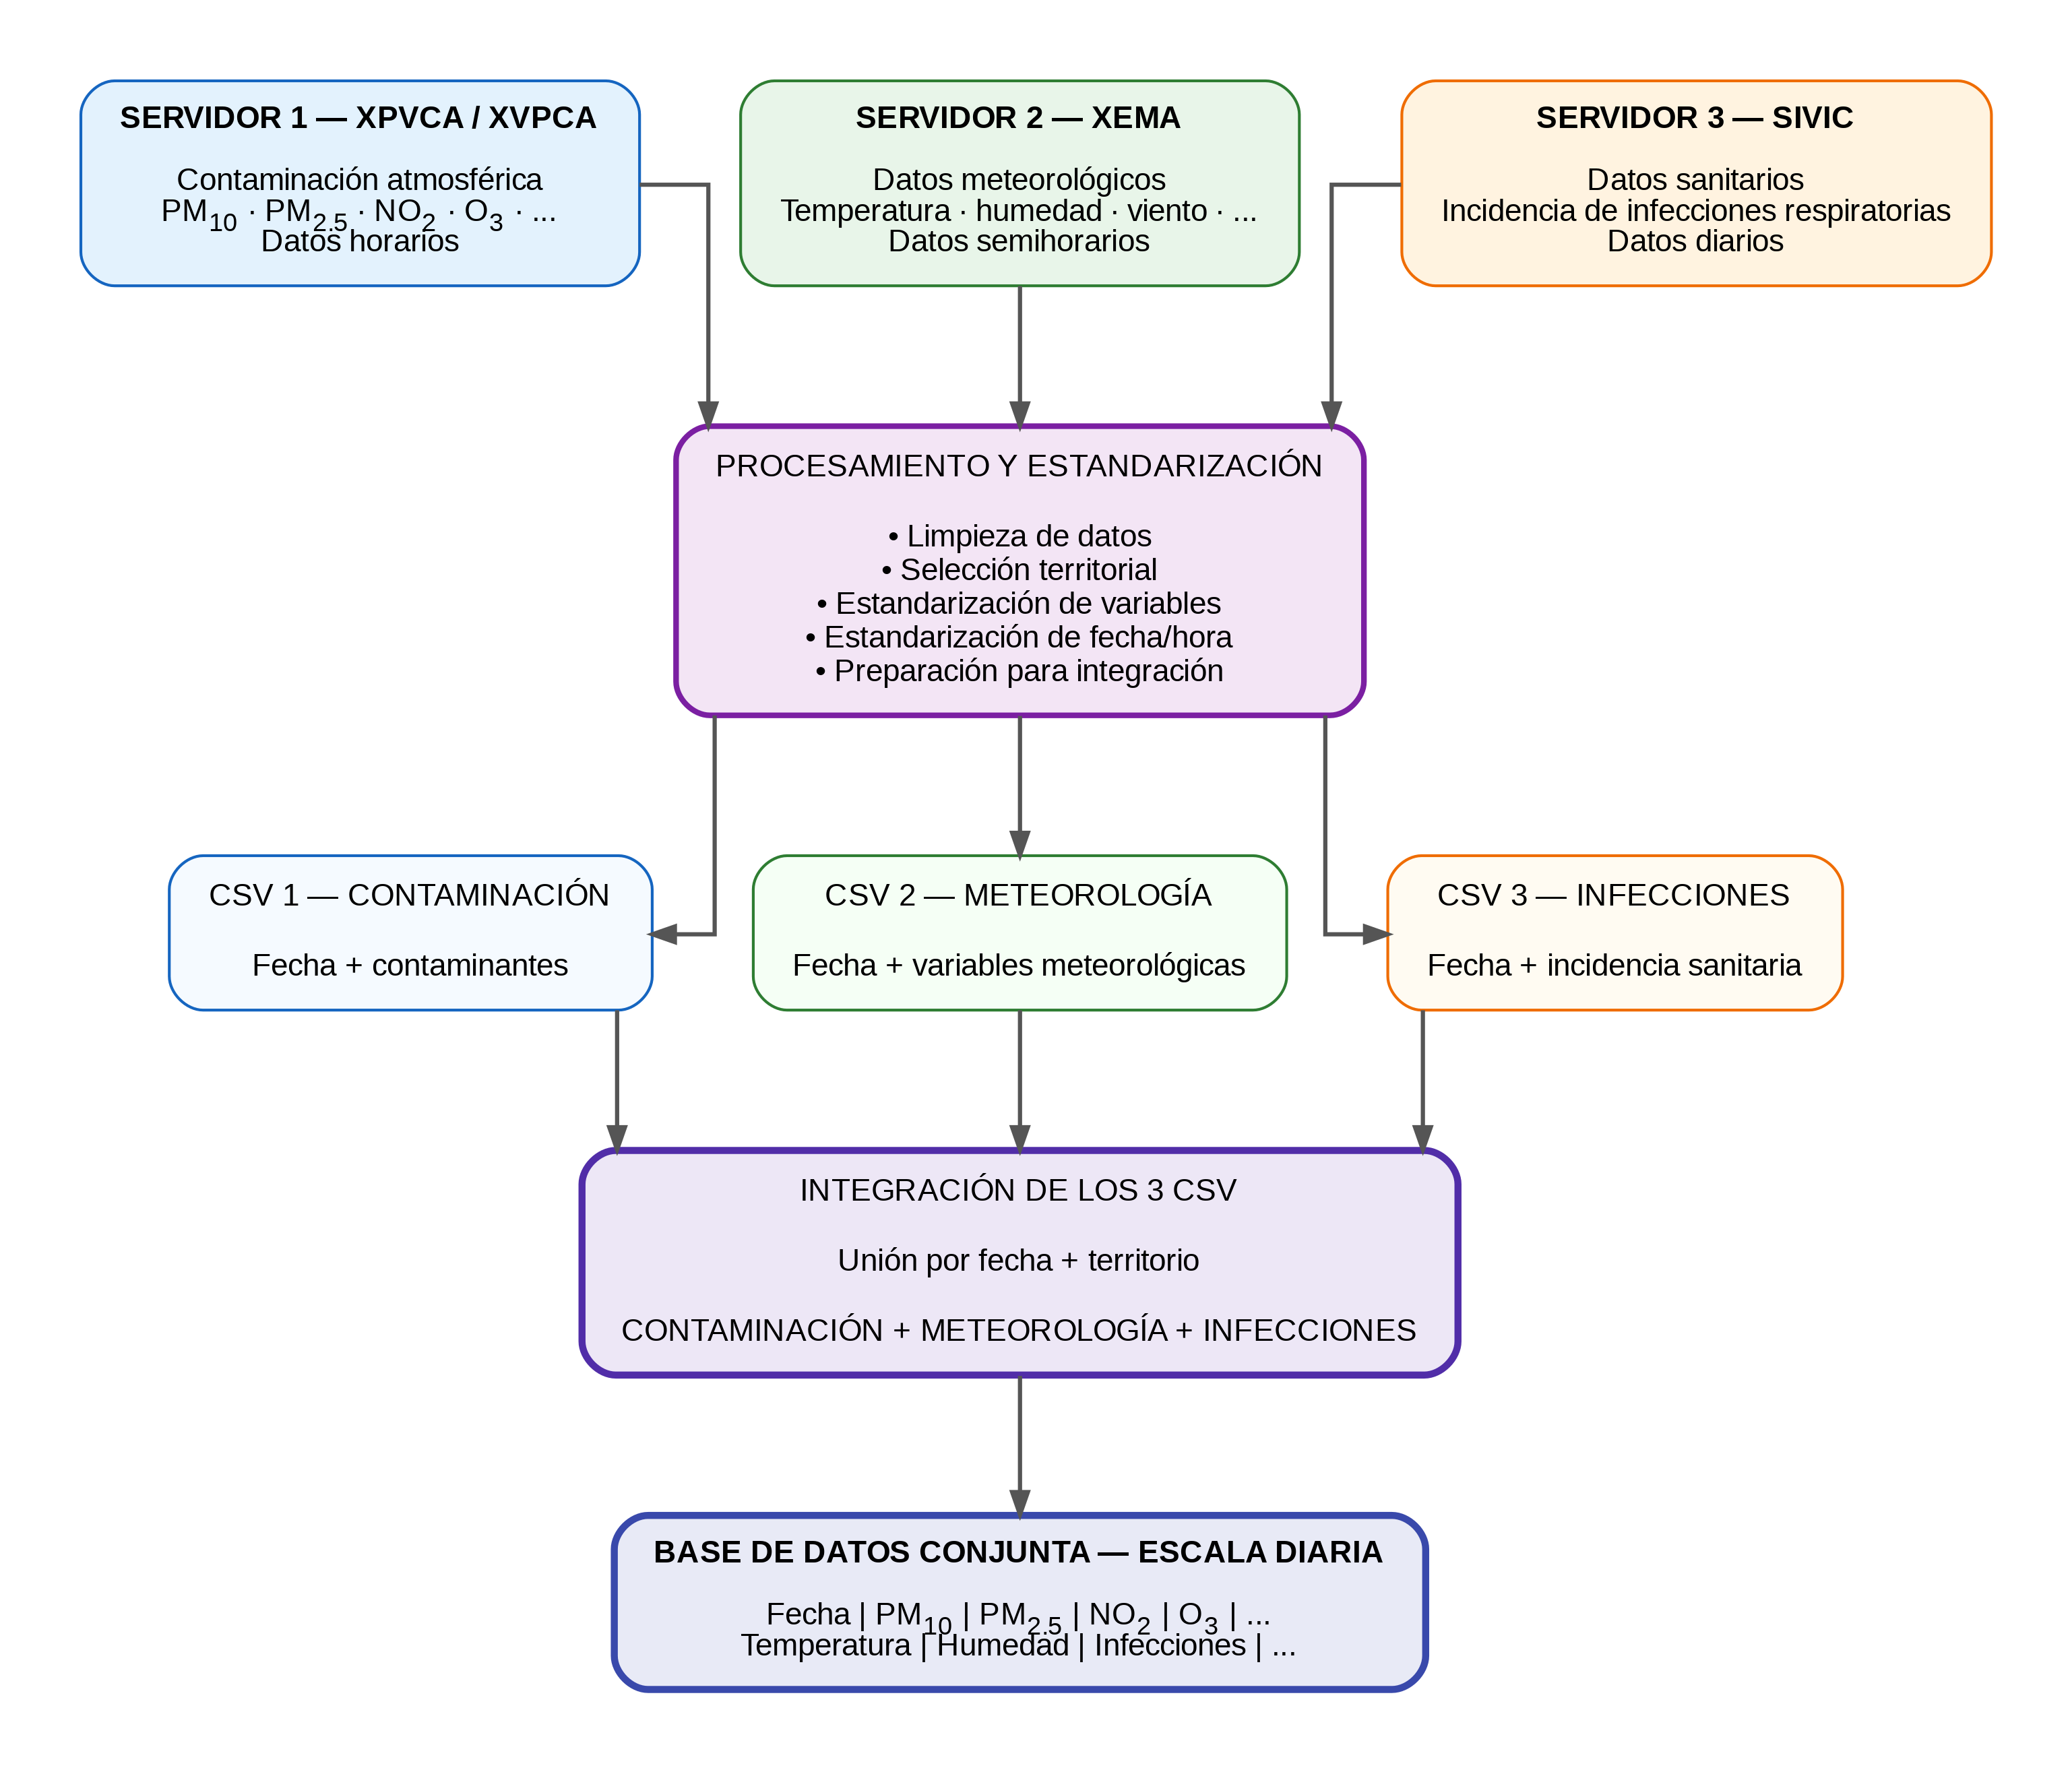


--- PARTE 2: DESDE BD CONJUNTA HASTA DIFUSIÓN ---


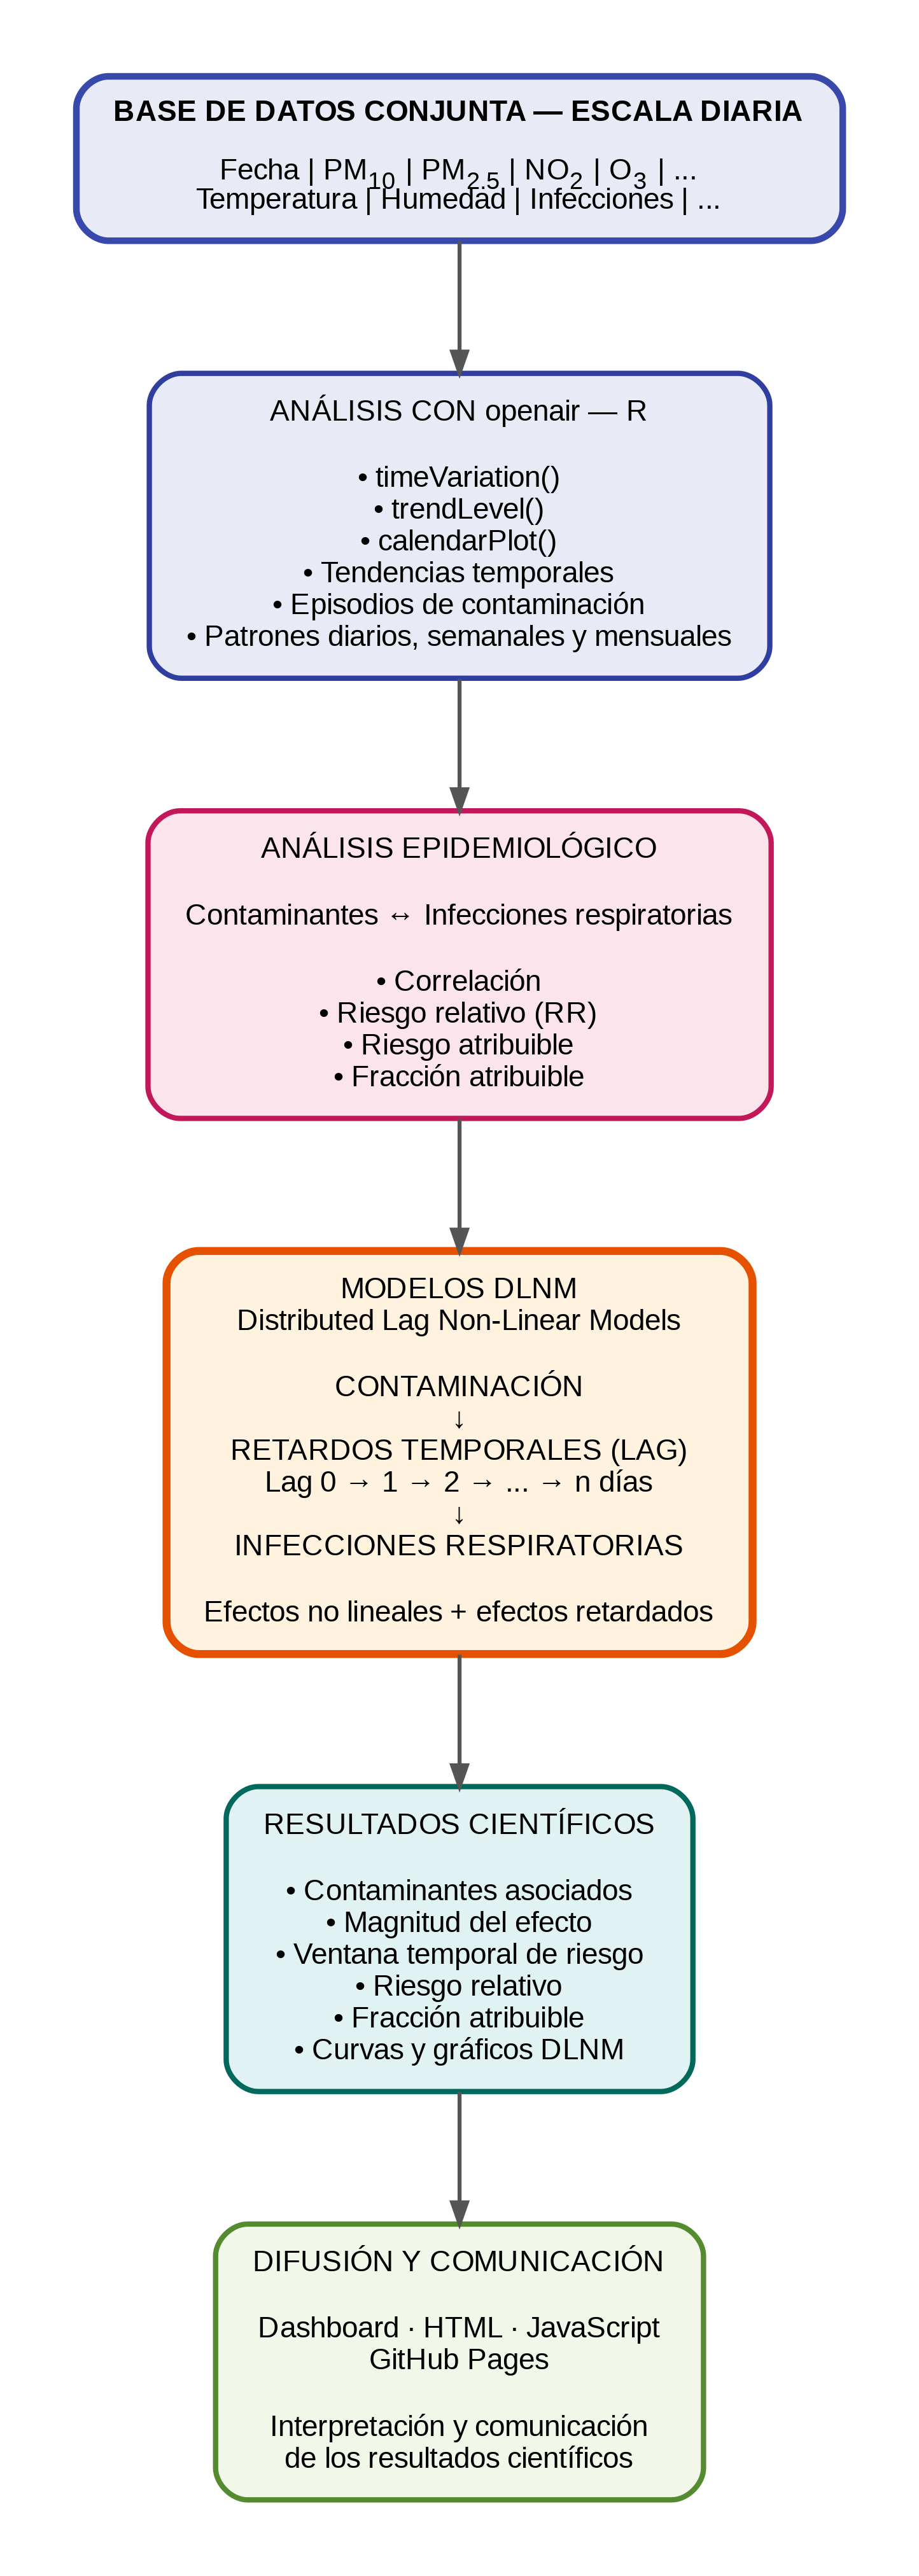

In [4]:

# ============================================================
# DIAGRAMA DE FLUJO - EPIDEMIOLOGÍA AMBIENTAL (EN 2 PARTES)
# ORIENTACIÓN: ARRIBA → ABAJO | RESOLUCIÓN: 300 DPI
# Google Colab + Graphviz
# ============================================================

!apt-get -qq install graphviz
!pip install -q graphviz

from graphviz import Digraph
from IPython.display import display, Image

# Estilos globales para ambos diagramas
def aplicar_estilos_base(dot):
    dot.attr(
        rankdir="TB",
        bgcolor="white",
        pad="0.4",
        nodesep="0.5",
        ranksep="0.7",
        splines="ortho",
        dpi="300"  # Alta resolución (300 DPI)
    )
    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        fontname="Arial",
        fontsize="11",
        margin="0.2,0.12"
    )
    dot.attr(
        "edge",
        color="#555555",
        penwidth="1.5",
        arrowsize="0.8",
        fontname="Arial",
        fontsize="9"
    )

# ============================================================
# PARTE 1: SERVIDORES DE DATOS → BASE DE DATOS CONJUNTA
# ============================================================

dot1 = Digraph("flujo_parte_1", format="png")
aplicar_estilos_base(dot1)

# Nodos Parte 1
dot1.node(
    "xpvca",
    "<<b>SERVIDOR 1 — XPVCA / XVPCA</b><br/><br/>"
    "Contaminación atmosférica<br/>"
    "PM<sub>10</sub> · PM<sub>2.5</sub> · NO<sub>2</sub> · O<sub>3</sub> · ...<br/>"
    "Datos horarios>",
    fillcolor="#E3F2FD",
    color="#1565C0"
)

dot1.node(
    "xema",
    "<<b>SERVIDOR 2 — XEMA</b><br/><br/>"
    "Datos meteorológicos<br/>"
    "Temperatura · humedad · viento · ...<br/>"
    "Datos semihorarios>",
    fillcolor="#E8F5E9",
    color="#2E7D32"
)

dot1.node(
    "sivic",
    "<<b>SERVIDOR 3 — SIVIC</b><br/><br/>"
    "Datos sanitarios<br/>"
    "Incidencia de infecciones respiratorias<br/>"
    "Datos diarios>",
    fillcolor="#FFF3E0",
    color="#EF6C00"
)

dot1.node(
    "procesamiento",
    "PROCESAMIENTO Y ESTANDARIZACIÓN\n\n"
    "• Limpieza de datos\n"
    "• Selección territorial\n"
    "• Estandarización de variables\n"
    "• Estandarización de fecha/hora\n"
    "• Preparación para integración",
    fillcolor="#F3E5F5",
    color="#7B1FA2",
    penwidth="2"
)

dot1.node(
    "csv_air",
    "CSV 1 — CONTAMINACIÓN\n\nFecha + contaminantes",
    fillcolor="#F5FAFF",
    color="#1565C0"
)

dot1.node(
    "csv_weather",
    "CSV 2 — METEOROLOGÍA\n\nFecha + variables meteorológicas",
    fillcolor="#F5FFF5",
    color="#2E7D32"
)

dot1.node(
    "csv_health",
    "CSV 3 — INFECCIONES\n\nFecha + incidencia sanitaria",
    fillcolor="#FFFBF2",
    color="#EF6C00"
)

dot1.node(
    "merge",
    "INTEGRACIÓN DE LOS 3 CSV\n\n"
    "Unión por fecha + territorio\n\n"
    "CONTAMINACIÓN + METEOROLOGÍA + INFECCIONES",
    fillcolor="#EDE7F6",
    color="#512DA8",
    penwidth="2.5"
)

dot1.node(
    "daily",
    "<<b>BASE DE DATOS CONJUNTA — ESCALA DIARIA</b><br/><br/>"
    "Fecha | PM<sub>10</sub> | PM<sub>2.5</sub> | NO<sub>2</sub> | O<sub>3</sub> | ...<br/>"
    "Temperatura | Humedad | Infecciones | ...>",
    fillcolor="#E8EAF6",
    color="#3949AB",
    penwidth="2.5"
)

# Conexiones Parte 1
dot1.edge("xpvca", "procesamiento")
dot1.edge("xema", "procesamiento")
dot1.edge("sivic", "procesamiento")

dot1.edge("procesamiento", "csv_air")
dot1.edge("procesamiento", "csv_weather")
dot1.edge("procesamiento", "csv_health")

dot1.edge("csv_air", "merge")
dot1.edge("csv_weather", "merge")
dot1.edge("csv_health", "merge")

dot1.edge("merge", "daily")

# Renderizar y guardar Parte 1
dot1.render("/content/flujo_parte1_bd_conjunta", cleanup=True)


# ============================================================
# PARTE 2: BASE DE DATOS CONJUNTA → DIFUSIÓN Y COMUNICACIÓN
# ============================================================

dot2 = Digraph("flujo_parte_2", format="png")
aplicar_estilos_base(dot2)

# Nodos Parte 2
dot2.node(
    "daily",
    "<<b>BASE DE DATOS CONJUNTA — ESCALA DIARIA</b><br/><br/>"
    "Fecha | PM<sub>10</sub> | PM<sub>2.5</sub> | NO<sub>2</sub> | O<sub>3</sub> | ...<br/>"
    "Temperatura | Humedad | Infecciones | ...>",
    fillcolor="#E8EAF6",
    color="#3949AB",
    penwidth="2.5"
)

dot2.node(
    "openair",
    "ANÁLISIS CON openair — R\n\n"
    "• timeVariation()\n"
    "• trendLevel()\n"
    "• calendarPlot()\n"
    "• Tendencias temporales\n"
    "• Episodios de contaminación\n"
    "• Patrones diarios, semanales y mensuales",
    fillcolor="#E8EAF6",
    color="#303F9F",
    penwidth="2"
)

dot2.node(
    "epi",
    "ANÁLISIS EPIDEMIOLÓGICO\n\n"
    "Contaminantes ↔ Infecciones respiratorias\n\n"
    "• Correlación\n"
    "• Riesgo relativo (RR)\n"
    "• Riesgo atribuible\n"
    "• Fracción atribuible",
    fillcolor="#FCE4EC",
    color="#C2185B",
    penwidth="2"
)

dot2.node(
    "dlnm",
    "MODELOS DLNM\n"
    "Distributed Lag Non-Linear Models\n\n"
    "CONTAMINACIÓN\n"
    "↓\n"
    "RETARDOS TEMPORALES (LAG)\n"
    "Lag 0 → 1 → 2 → ... → n días\n"
    "↓\n"
    "INFECCIONES RESPIRATORIAS\n\n"
    "Efectos no lineales + efectos retardados",
    fillcolor="#FFF3E0",
    color="#E65100",
    penwidth="3"
)

dot2.node(
    "results",
    "RESULTADOS CIENTÍFICOS\n\n"
    "• Contaminantes asociados\n"
    "• Magnitud del efecto\n"
    "• Ventana temporal de riesgo\n"
    "• Riesgo relativo\n"
    "• Fracción atribuible\n"
    "• Curvas y gráficos DLNM",
    fillcolor="#E0F2F1",
    color="#00695C",
    penwidth="2"
)

dot2.node(
    "web",
    "DIFUSIÓN Y COMUNICACIÓN\n\n"
    "Dashboard · HTML · JavaScript\n"
    "GitHub Pages\n\n"
    "Interpretación y comunicación\n"
    "de los resultados científicos",
    fillcolor="#F1F8E9",
    color="#558B2F",
    penwidth="2"
)

# Conexiones Parte 2
dot2.edge("daily", "openair")
dot2.edge("openair", "epi")
dot2.edge("epi", "dlnm")
dot2.edge("dlnm", "results")
dot2.edge("results", "web")

# Renderizar y guardar Parte 2
dot2.render("/content/flujo_parte2_analisis_difusion", cleanup=True)

# ============================================================
# MOSTRAR EN COLAB
# ============================================================

print("--- PARTE 1: DESDE SERVIDORES HASTA BD CONJUNTA ---")
display(Image("/content/flujo_parte1_bd_conjunta.png"))

print("\n--- PARTE 2: DESDE BD CONJUNTA HASTA DIFUSIÓN ---")
display(Image("/content/flujo_parte2_analisis_difusion.png"))

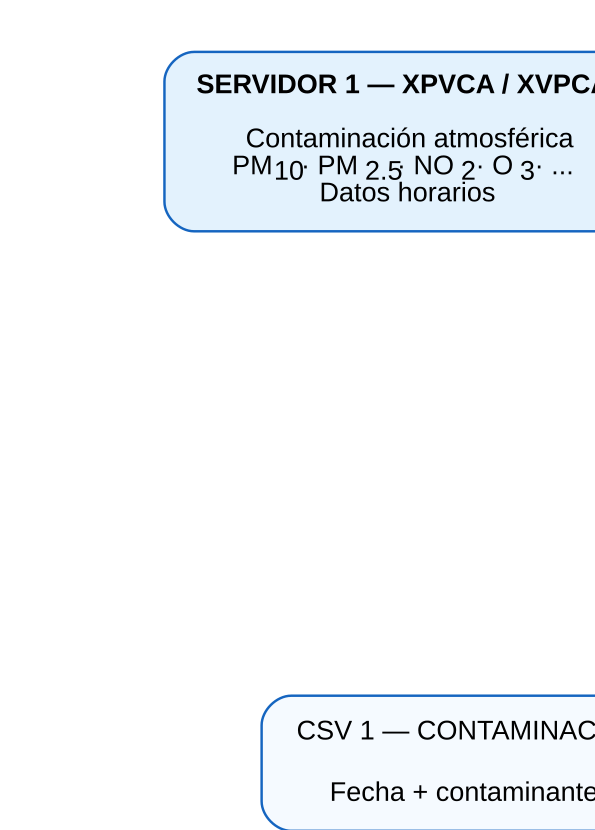

PNG guardado correctamente en:
/content/flujo_epidemiologia_ambiental_a4.png


In [2]:

# ============================================================
# DIAGRAMA DEL FLUJO DE TRABAJO - EPIDEMIOLOGÍA AMBIENTAL
# ORIENTACIÓN: ARRIBA → ABAJO | FORMATO: DIN A4
# Google Colab + Graphviz
# ============================================================

!apt-get -qq install graphviz
!pip install -q graphviz

from graphviz import Digraph
from IPython.display import display

# ------------------------------------------------------------
# CREAR DIAGRAMA
# ------------------------------------------------------------

dot = Digraph(
    "flujo_epidemiologia_ambiental",
    format="png"
)

# ------------------------------------------------------------
# CONFIGURACIÓN TAMAÑO DIN A4 (8.27 x 11.69 PULGADAS)
# ------------------------------------------------------------
dot.attr(
    rankdir="TB",
    bgcolor="white",
    pad="0.3",
    nodesep="0.4",
    ranksep="0.6",
    splines="ortho",
    size="8.27,11.69!",  # Forzar proporción DIN A4
    ratio="fill",        # Ajustar contenido al A4
    dpi="300"            # Alta resolución
)

# Estilo de nodos
dot.attr(
    "node",
    shape="box",
    style="rounded,filled",
    fontname="Arial",
    fontsize="11",
    margin="0.18,0.12"
)

# Estilo de flechas
dot.attr(
    "edge",
    color="#555555",
    penwidth="1.5",
    arrowsize="0.8",
    fontname="Arial",
    fontsize="9"
)

# ============================================================
# 1. SERVIDORES DE DATOS
# ============================================================

dot.node(
    "xpvca",
    "<<b>SERVIDOR 1 — XPVCA / XVPCA</b><br/><br/>"
    "Contaminación atmosférica<br/>"
    "PM<sub>10</sub> · PM<sub>2.5</sub> · NO<sub>2</sub> · O<sub>3</sub> · ...<br/>"
    "Datos horarios>",
    fillcolor="#E3F2FD",
    color="#1565C0"
)

dot.node(
    "xema",
    "<<b>SERVIDOR 2 — XEMA</b><br/><br/>"
    "Datos meteorológicos<br/>"
    "Temperatura · humedad · viento · ...<br/>"
    "Datos semihorarios>",
    fillcolor="#E8F5E9",
    color="#2E7D32"
)

dot.node(
    "sivic",
    "<<b>SERVIDOR 3 — SIVIC</b><br/><br/>"
    "Datos sanitarios<br/>"
    "Incidencia de infecciones respiratorias<br/>"
    "Datos diarios>",
    fillcolor="#FFF3E0",
    color="#EF6C00"
)

# ============================================================
# 2. PROCESAMIENTO
# ============================================================

dot.node(
    "procesamiento",
    "PROCESAMIENTO Y ESTANDARIZACIÓN\n\n"
    "• Limpieza de datos\n"
    "• Selección territorial\n"
    "• Estandarización de variables\n"
    "• Estandarización de fecha/hora\n"
    "• Preparación para integración",
    fillcolor="#F3E5F5",
    color="#7B1FA2",
    penwidth="2"
)

# ============================================================
# 3. CSV INDIVIDUALES
# ============================================================

dot.node(
    "csv_air",
    "CSV 1 — CONTAMINACIÓN\n\n"
    "Fecha + contaminantes",
    fillcolor="#F5FAFF",
    color="#1565C0"
)

dot.node(
    "csv_weather",
    "CSV 2 — METEOROLOGÍA\n\n"
    "Fecha + variables meteorológicas",
    fillcolor="#F5FFF5",
    color="#2E7D32"
)

dot.node(
    "csv_health",
    "CSV 3 — INFECCIONES\n\n"
    "Fecha + incidencia sanitaria",
    fillcolor="#FFFBF2",
    color="#EF6C00"
)

# ============================================================
# 4. INTEGRACIÓN
# ============================================================

dot.node(
    "merge",
    "INTEGRACIÓN DE LOS 3 CSV\n\n"
    "Unión por fecha + territorio\n\n"
    "CONTAMINACIÓN + METEOROLOGÍA + INFECCIONES",
    fillcolor="#EDE7F6",
    color="#512DA8",
    penwidth="2.5"
)

# ============================================================
# 5. BASE DE DATOS CONJUNTA
# ============================================================

dot.node(
    "daily",
    "<<b>BASE DE DATOS CONJUNTA — ESCALA DIARIA</b><br/><br/>"
    "Fecha | PM<sub>10</sub> | PM<sub>2.5</sub> | NO<sub>2</sub> | O<sub>3</sub> | ...<br/>"
    "Temperatura | Humedad | Infecciones | ...>",
    fillcolor="#E8EAF6",
    color="#3949AB",
    penwidth="2"
)

# ============================================================
# 6. OPENAIR
# ============================================================

dot.node(
    "openair",
    "ANÁLISIS CON openair — R\n\n"
    "• timeVariation()\n"
    "• trendLevel()\n"
    "• calendarPlot()\n"
    "• Tendencias temporales\n"
    "• Episodios de contaminación\n"
    "• Patrones diarios, semanales y mensuales",
    fillcolor="#E8EAF6",
    color="#303F9F",
    penwidth="2"
)

# ============================================================
# 7. ANÁLISIS EPIDEMIOLÓGICO
# ============================================================

dot.node(
    "epi",
    "ANÁLISIS EPIDEMIOLÓGICO\n\n"
    "Contaminantes ↔ Infecciones respiratorias\n\n"
    "• Correlación\n"
    "• Riesgo relativo (RR)\n"
    "• Riesgo atribuible\n"
    "• Fracción atribuible",
    fillcolor="#FCE4EC",
    color="#C2185B",
    penwidth="2"
)

# ============================================================
# 8. DLNM
# ============================================================

dot.node(
    "dlnm",
    "MODELOS DLNM\n"
    "Distributed Lag Non-Linear Models\n\n"
    "CONTAMINACIÓN\n"
    "↓\n"
    "RETARDOS TEMPORALES (LAG)\n"
    "Lag 0 → 1 → 2 → ... → n días\n"
    "↓\n"
    "INFECCIONES RESPIRATORIAS\n\n"
    "Efectos no lineales + efectos retardados",
    fillcolor="#FFF3E0",
    color="#E65100",
    penwidth="3"
)

# ============================================================
# 9. RESULTADOS
# ============================================================

dot.node(
    "results",
    "RESULTADOS CIENTÍFICOS\n\n"
    "• Contaminantes asociados\n"
    "• Magnitud del efecto\n"
    "• Ventana temporal de riesgo\n"
    "• Riesgo relativo\n"
    "• Fracción atribuible\n"
    "• Curvas y gráficos DLNM",
    fillcolor="#E0F2F1",
    color="#00695C",
    penwidth="2"
)

# ============================================================
# 10. DIFUSIÓN
# ============================================================

dot.node(
    "web",
    "DIFUSIÓN Y COMUNICACIÓN\n\n"
    "Dashboard · HTML · JavaScript\n"
    "GitHub Pages\n\n"
    "Interpretación y comunicación\n"
    "de los resultados científicos",
    fillcolor="#F1F8E9",
    color="#558B2F",
    penwidth="2"
)

# ============================================================
# CONEXIONES
# ============================================================

dot.edge("xpvca", "procesamiento")
dot.edge("xema", "procesamiento")
dot.edge("sivic", "procesamiento")

dot.edge("procesamiento", "csv_air")
dot.edge("procesamiento", "csv_weather")
dot.edge("procesamiento", "csv_health")

dot.edge("csv_air", "merge")
dot.edge("csv_weather", "merge")
dot.edge("csv_health", "merge")

dot.edge("merge", "daily")
dot.edge("daily", "openair")
dot.edge("openair", "epi")
dot.edge("epi", "dlnm")
dot.edge("dlnm", "results")
dot.edge("results", "web")

# ============================================================
# MOSTRAR Y GUARDAR
# ============================================================

display(dot)

dot.render(
    "/content/flujo_epidemiologia_ambiental_a4",
    cleanup=True
)

print("PNG guardado correctamente en:")
print("/content/flujo_epidemiologia_ambiental_a4.png")

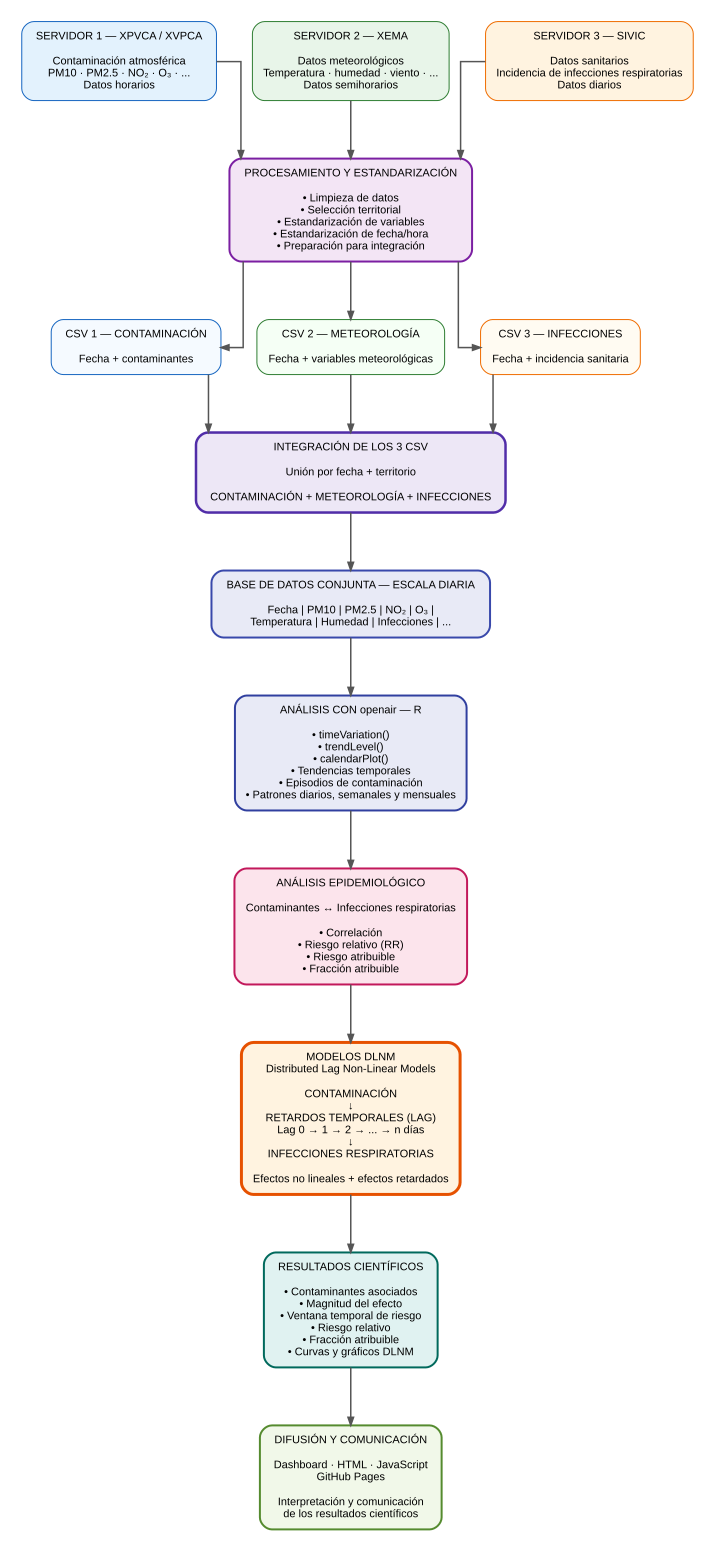

PNG guardado en:
/content/flujo_epidemiologia_ambiental_vertical.png


In [ ]:
# ============================================================
# DIAGRAMA DEL FLUJO DE TRABAJO - EPIDEMIOLOGÍA AMBIENTAL
# ORIENTACIÓN: ARRIBA → ABAJO
# Google Colab + Graphviz
# ============================================================

!apt-get -qq install graphviz
!pip install -q graphviz

from graphviz import Digraph
from IPython.display import display

# ------------------------------------------------------------
# CREAR DIAGRAMA
# ------------------------------------------------------------

dot = Digraph(
    "flujo_epidemiologia_ambiental",
    format="png"
)

# ARRIBA → ABAJO
dot.attr(
    rankdir="TB",
    bgcolor="white",
    pad="0.3",
    nodesep="0.5",
    ranksep="0.8",
    splines="ortho"
)

# Estilo de nodos
dot.attr(
    "node",
    shape="box",
    style="rounded,filled",
    fontname="Arial",
    fontsize="11",
    margin="0.18,0.12"
)

# Estilo de flechas
dot.attr(
    "edge",
    color="#555555",
    penwidth="1.5",
    arrowsize="0.8",
    fontname="Arial",
    fontsize="9"
)

# ============================================================
# 1. SERVIDORES DE DATOS
# ============================================================

dot.node(
    "xpvca",
    "SERVIDOR 1 — XPVCA / XVPCA\n\n"
    "Contaminación atmosférica\n"
    "PM10 · PM2.5 · NO₂ · O₃ · ...\n"
    "Datos horarios",
    fillcolor="#E3F2FD",
    color="#1565C0"
)

dot.node(
    "xema",
    "SERVIDOR 2 — XEMA\n\n"
    "Datos meteorológicos\n"
    "Temperatura · humedad · viento · ...\n"
    "Datos semihorarios",
    fillcolor="#E8F5E9",
    color="#2E7D32"
)

dot.node(
    "sivic",
    "SERVIDOR 3 — SIVIC\n\n"
    "Datos sanitarios\n"
    "Incidencia de infecciones respiratorias\n"
    "Datos diarios",
    fillcolor="#FFF3E0",
    color="#EF6C00"
)

# ============================================================
# 2. PROCESAMIENTO
# ============================================================

dot.node(
    "procesamiento",
    "PROCESAMIENTO Y ESTANDARIZACIÓN\n\n"
    "• Limpieza de datos\n"
    "• Selección territorial\n"
    "• Estandarización de variables\n"
    "• Estandarización de fecha/hora\n"
    "• Preparación para integración",
    fillcolor="#F3E5F5",
    color="#7B1FA2",
    penwidth="2"
)

# ============================================================
# 3. CSV INDIVIDUALES
# ============================================================

dot.node(
    "csv_air",
    "CSV 1 — CONTAMINACIÓN\n\n"
    "Fecha + contaminantes",
    fillcolor="#F5FAFF",
    color="#1565C0"
)

dot.node(
    "csv_weather",
    "CSV 2 — METEOROLOGÍA\n\n"
    "Fecha + variables meteorológicas",
    fillcolor="#F5FFF5",
    color="#2E7D32"
)

dot.node(
    "csv_health",
    "CSV 3 — INFECCIONES\n\n"
    "Fecha + incidencia sanitaria",
    fillcolor="#FFFBF2",
    color="#EF6C00"
)

# ============================================================
# 4. INTEGRACIÓN
# ============================================================

dot.node(
    "merge",
    "INTEGRACIÓN DE LOS 3 CSV\n\n"
    "Unión por fecha + territorio\n\n"
    "CONTAMINACIÓN + METEOROLOGÍA + INFECCIONES",
    fillcolor="#EDE7F6",
    color="#512DA8",
    penwidth="2.5"
)

# ============================================================
# 5. BASE DE DATOS CONJUNTA
# ============================================================

dot.node(
    "daily",
    "BASE DE DATOS CONJUNTA — ESCALA DIARIA\n\n"
    "Fecha | PM10 | PM2.5 | NO₂ | O₃ |\n"
    "Temperatura | Humedad | Infecciones | ...",
    fillcolor="#E8EAF6",
    color="#3949AB",
    penwidth="2"
)

# ============================================================
# 6. OPENAIR
# ============================================================

dot.node(
    "openair",
    "ANÁLISIS CON openair — R\n\n"
    "• timeVariation()\n"
    "• trendLevel()\n"
    "• calendarPlot()\n"
    "• Tendencias temporales\n"
    "• Episodios de contaminación\n"
    "• Patrones diarios, semanales y mensuales",
    fillcolor="#E8EAF6",
    color="#303F9F",
    penwidth="2"
)

# ============================================================
# 7. ANÁLISIS EPIDEMIOLÓGICO
# ============================================================

dot.node(
    "epi",
    "ANÁLISIS EPIDEMIOLÓGICO\n\n"
    "Contaminantes ↔ Infecciones respiratorias\n\n"
    "• Correlación\n"
    "• Riesgo relativo (RR)\n"
    "• Riesgo atribuible\n"
    "• Fracción atribuible",
    fillcolor="#FCE4EC",
    color="#C2185B",
    penwidth="2"
)

# ============================================================
# 8. DLNM
# ============================================================

dot.node(
    "dlnm",
    "MODELOS DLNM\n"
    "Distributed Lag Non-Linear Models\n\n"
    "CONTAMINACIÓN\n"
    "↓\n"
    "RETARDOS TEMPORALES (LAG)\n"
    "Lag 0 → 1 → 2 → ... → n días\n"
    "↓\n"
    "INFECCIONES RESPIRATORIAS\n\n"
    "Efectos no lineales + efectos retardados",
    fillcolor="#FFF3E0",
    color="#E65100",
    penwidth="3"
)

# ============================================================
# 9. RESULTADOS
# ============================================================

dot.node(
    "results",
    "RESULTADOS CIENTÍFICOS\n\n"
    "• Contaminantes asociados\n"
    "• Magnitud del efecto\n"
    "• Ventana temporal de riesgo\n"
    "• Riesgo relativo\n"
    "• Fracción atribuible\n"
    "• Curvas y gráficos DLNM",
    fillcolor="#E0F2F1",
    color="#00695C",
    penwidth="2"
)

# ============================================================
# 10. DIFUSIÓN
# ============================================================

dot.node(
    "web",
    "DIFUSIÓN Y COMUNICACIÓN\n\n"
    "Dashboard · HTML · JavaScript\n"
    "GitHub Pages\n\n"
    "Interpretación y comunicación\n"
    "de los resultados científicos",
    fillcolor="#F1F8E9",
    color="#558B2F",
    penwidth="2"
)

# ============================================================
# CONEXIONES
# ============================================================

# Tres servidores → procesamiento
dot.edge("xpvca", "procesamiento")
dot.edge("xema", "procesamiento")
dot.edge("sivic", "procesamiento")

# Procesamiento → CSV
dot.edge("procesamiento", "csv_air")
dot.edge("procesamiento", "csv_weather")
dot.edge("procesamiento", "csv_health")

# CSV → integración
dot.edge("csv_air", "merge")
dot.edge("csv_weather", "merge")
dot.edge("csv_health", "merge")

# Integración → base conjunta
dot.edge("merge", "daily")

# Base conjunta → openair
dot.edge("daily", "openair")

# openair → epidemiología
dot.edge("openair", "epi")

# Epidemiología → DLNM
dot.edge("epi", "dlnm")

# DLNM → resultados
dot.edge("dlnm", "results")

# Resultados → difusión
dot.edge("results", "web")

# ============================================================
# MOSTRAR
# ============================================================

display(dot)

# Guardar PNG
dot.render(
    "/content/flujo_epidemiologia_ambiental_vertical",
    cleanup=True
)

print("PNG guardado en:")
print("/content/flujo_epidemiologia_ambiental_vertical.png")

--- PARTE 1: DESDE SERVIDORES HASTA BD CONJUNTA ---


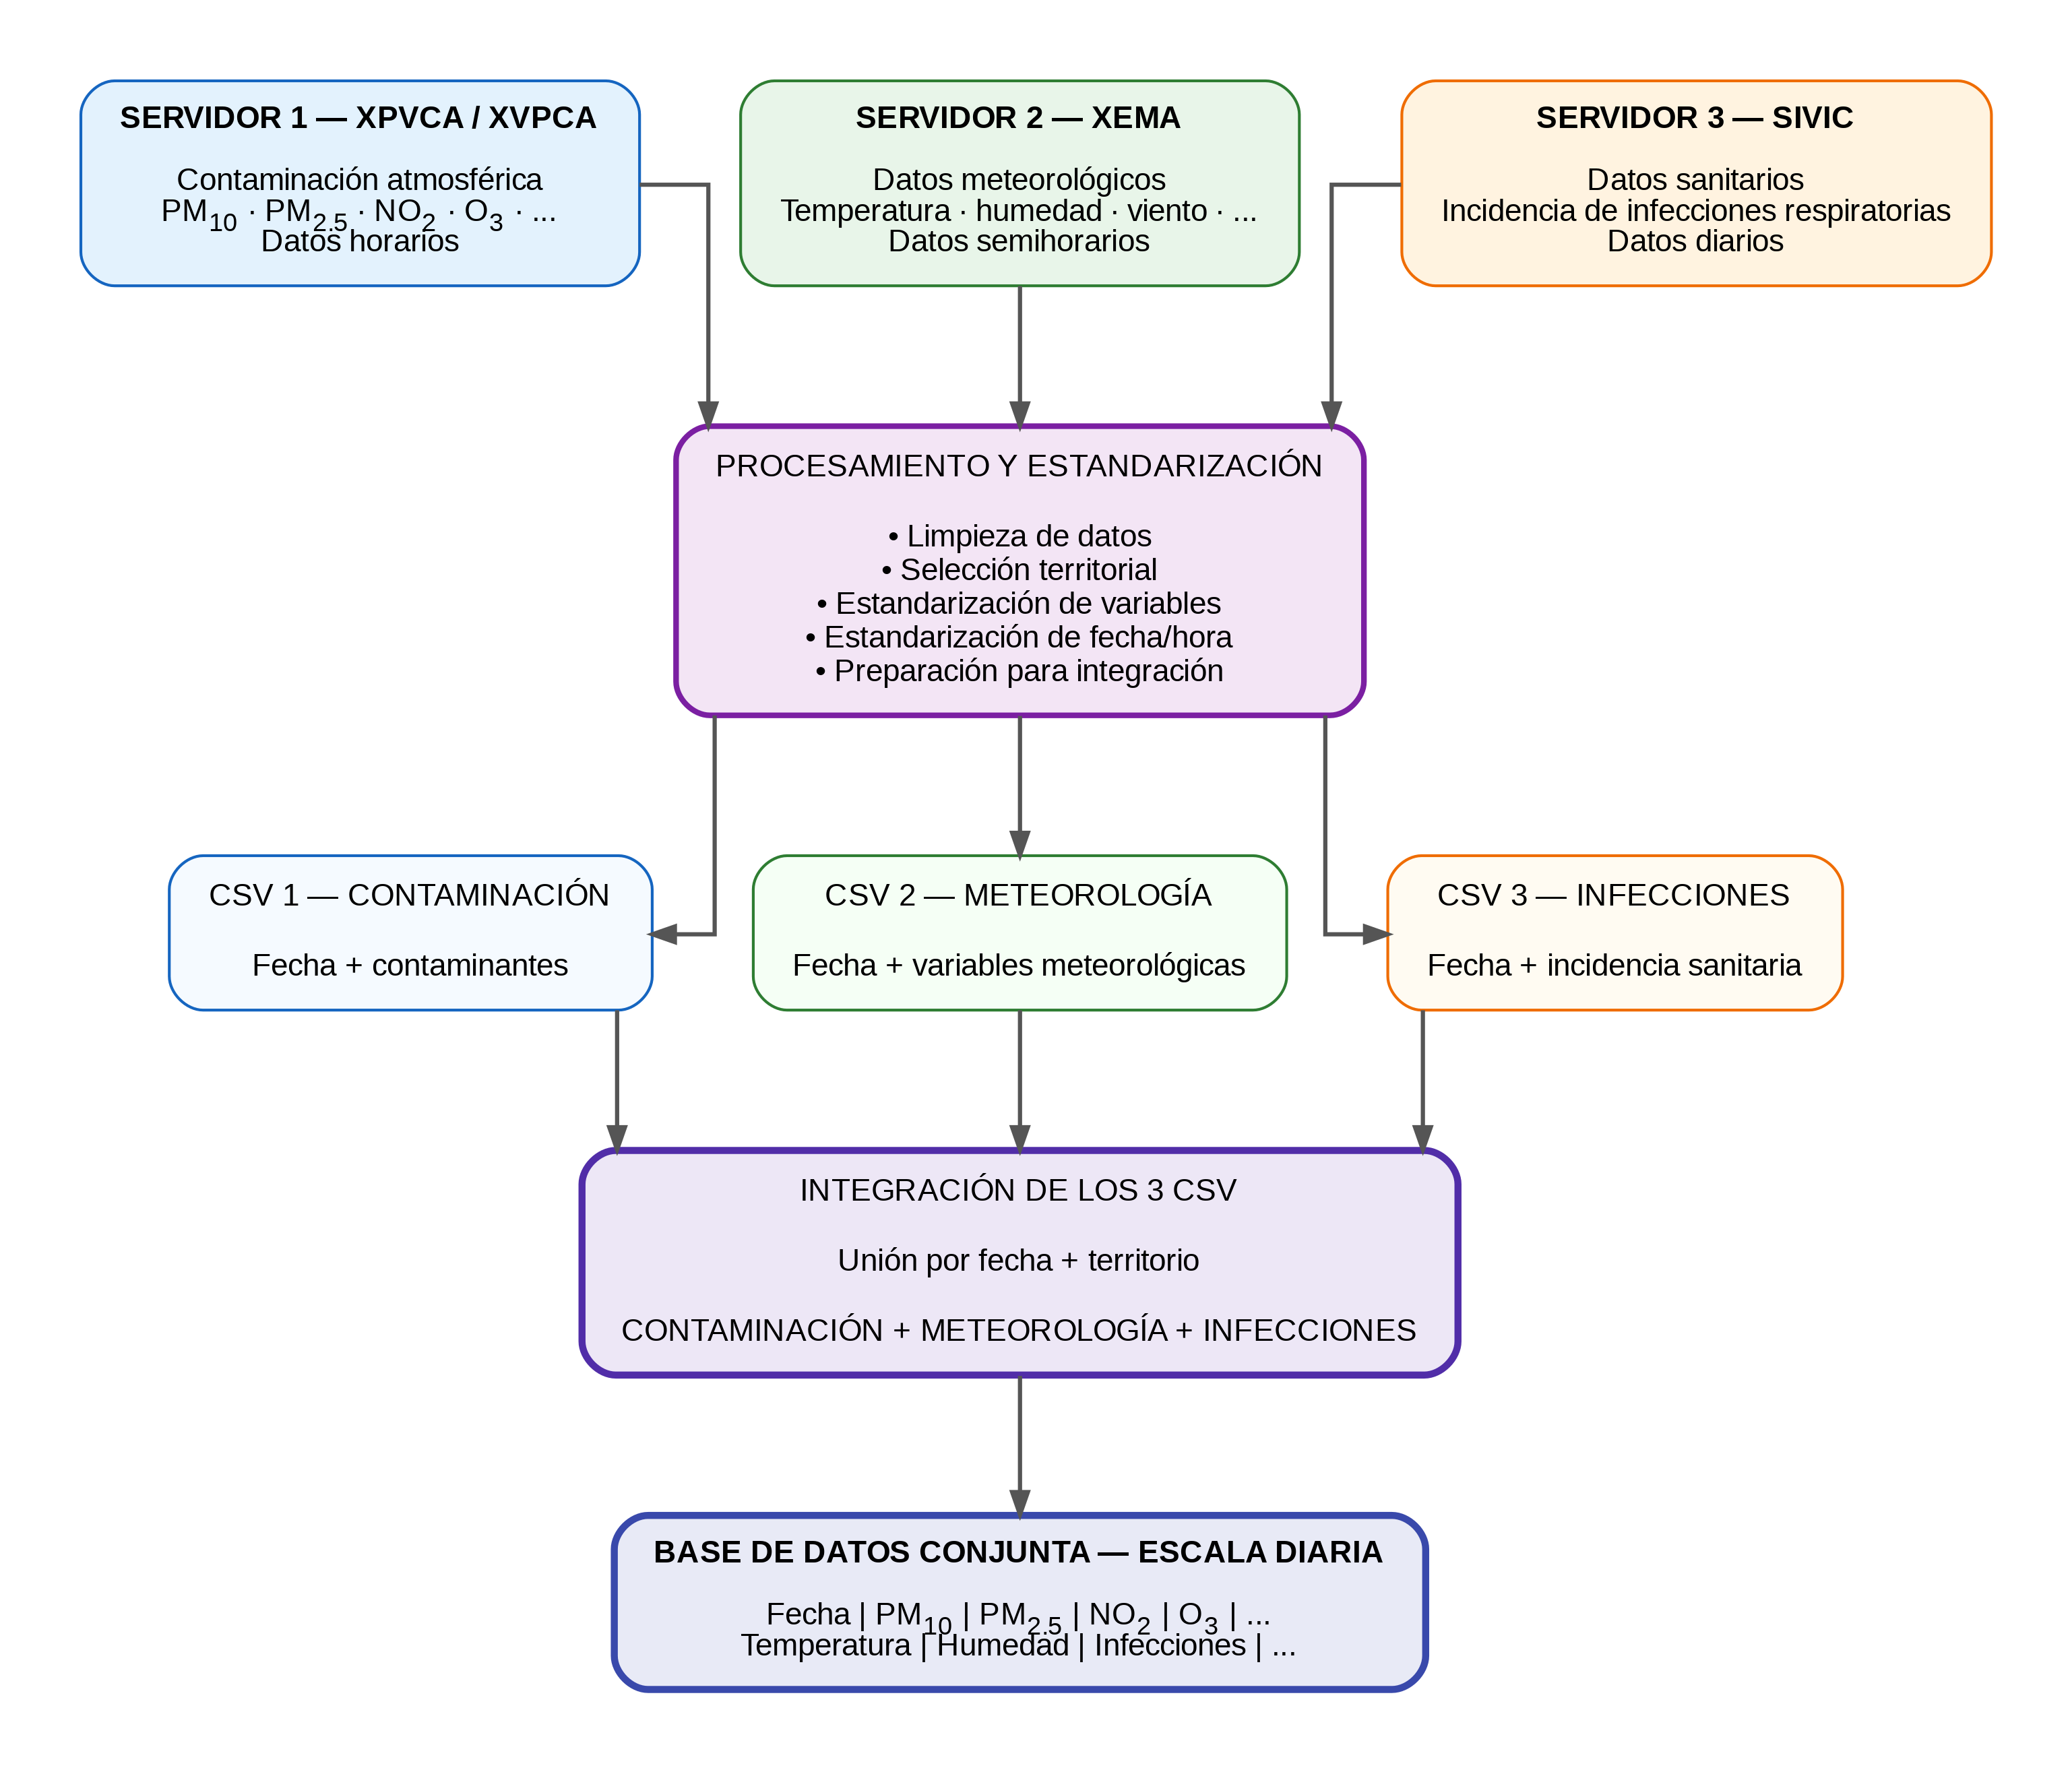


--- PARTE 2: DESDE BD CONJUNTA HASTA DIFUSIÓN (3 MÓDULOS A LA MISMA ALTURA) ---


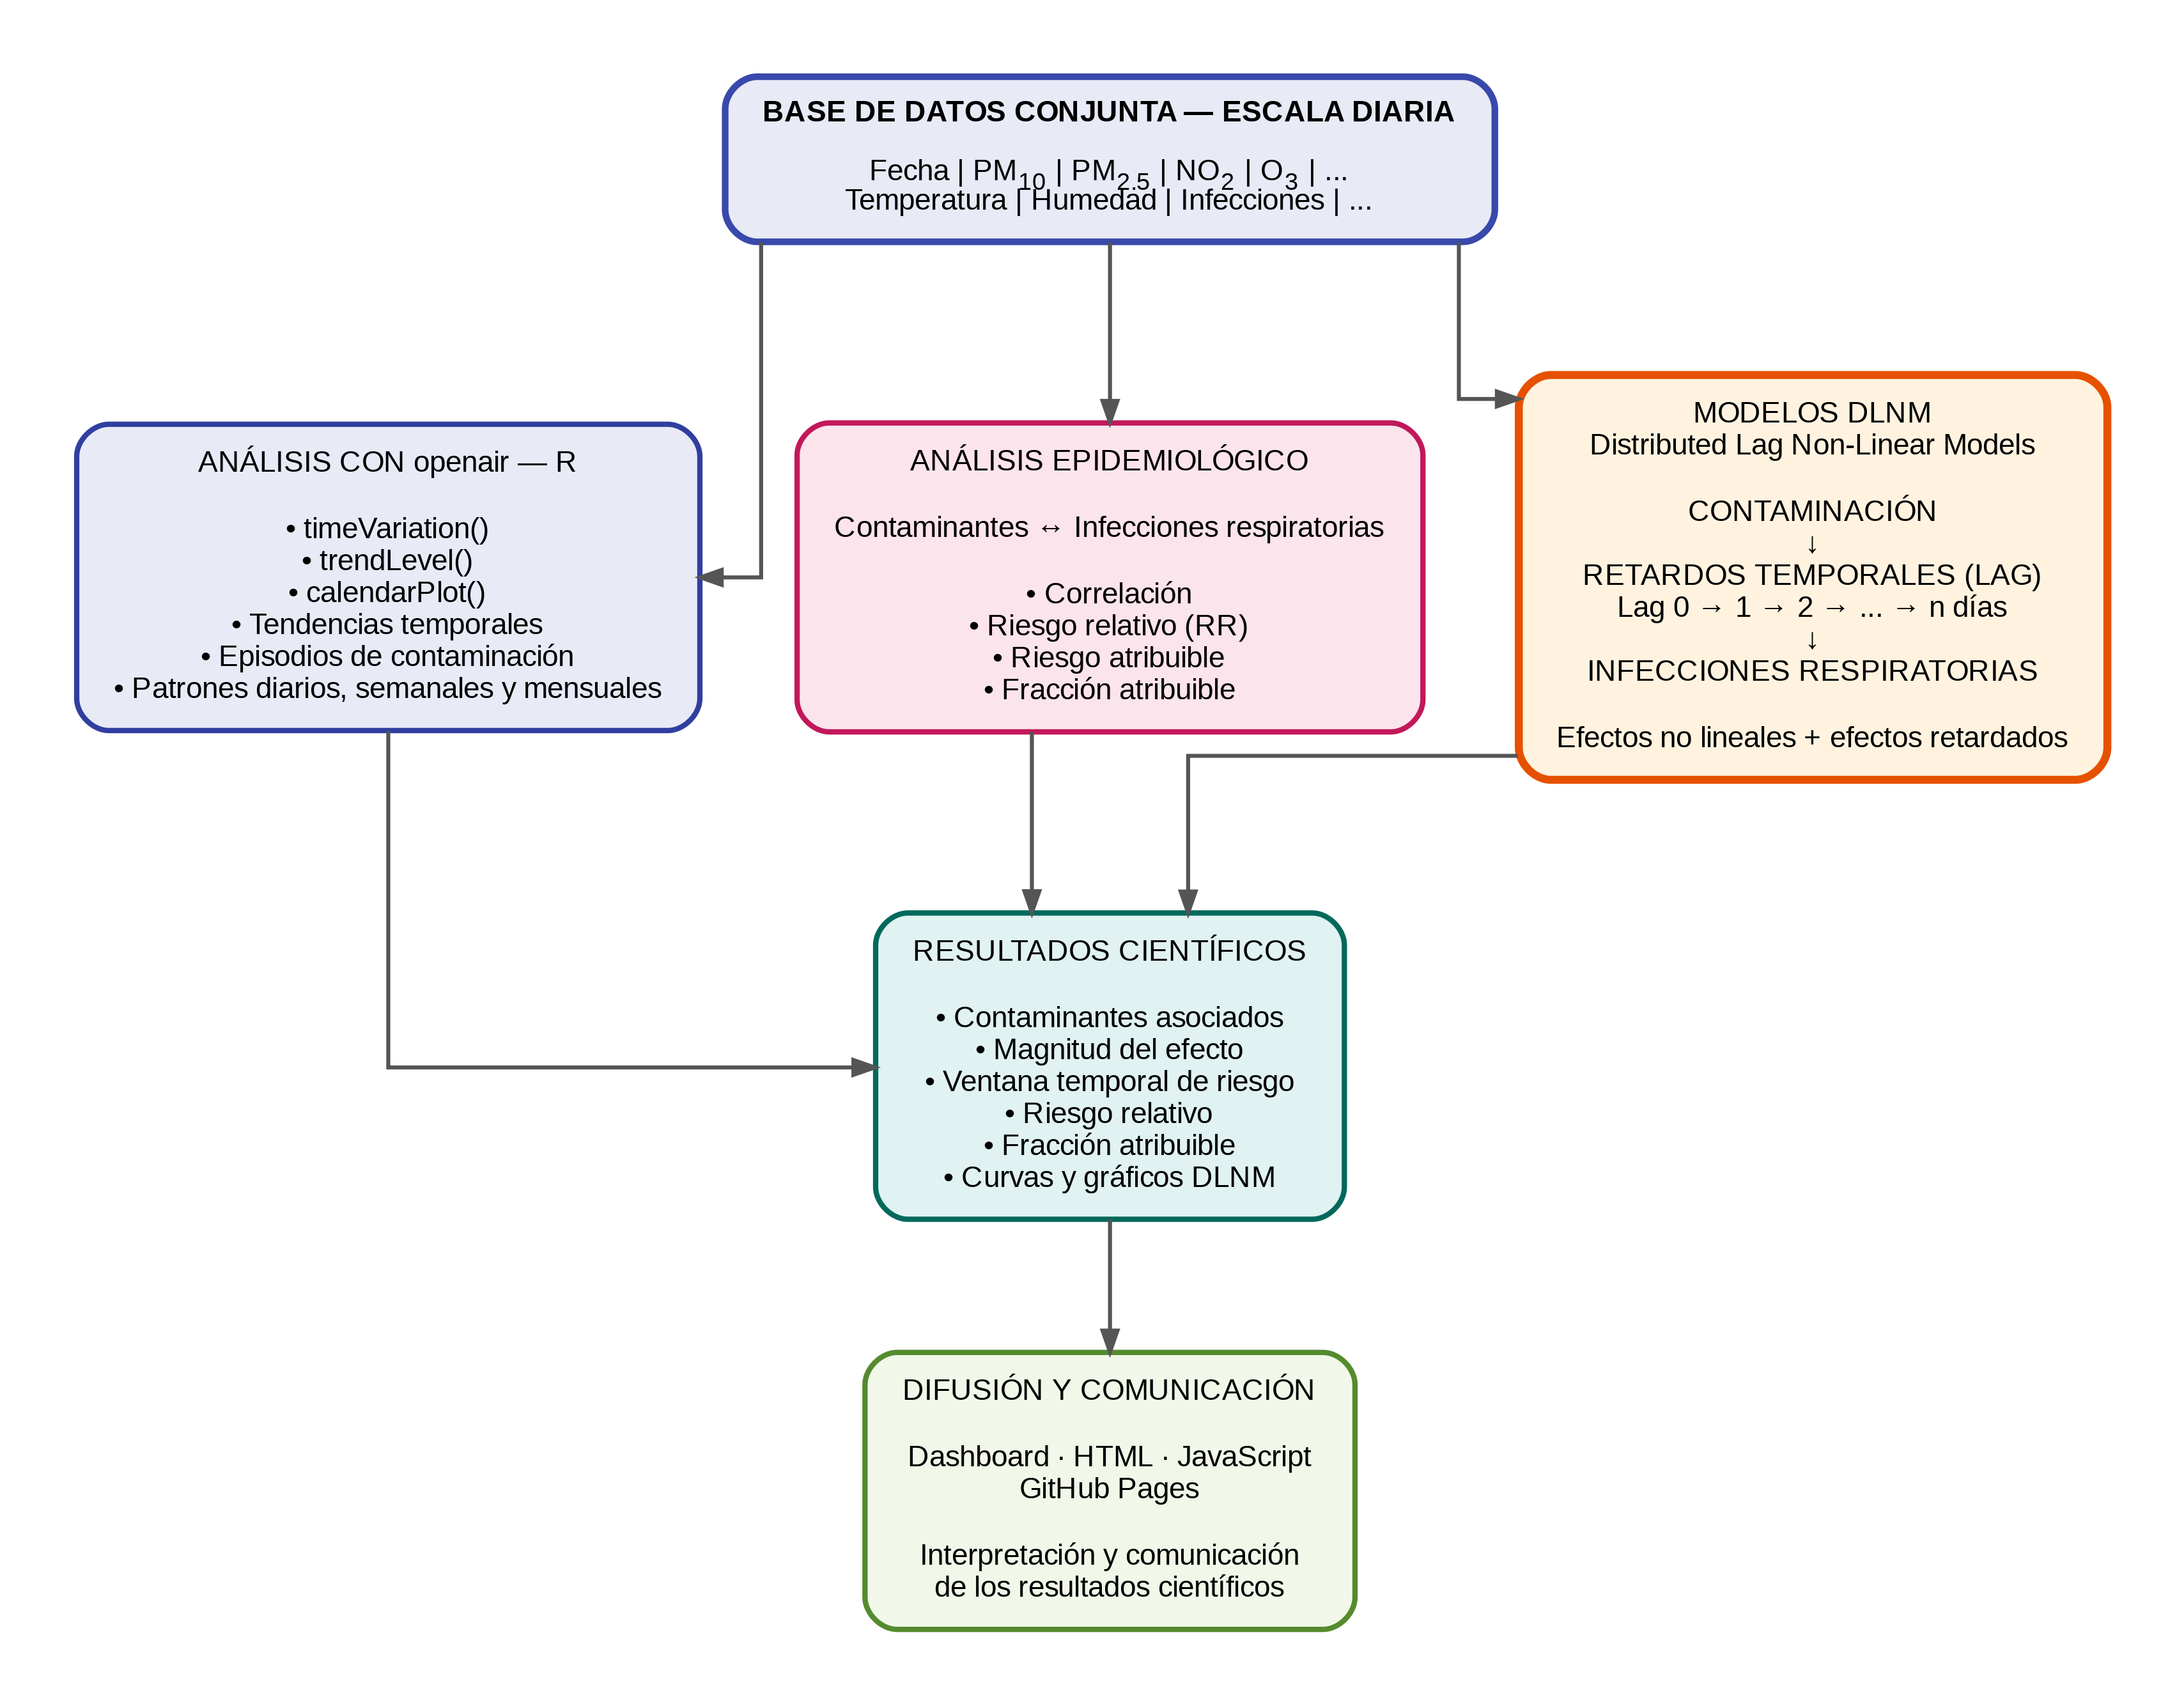

In [1]:
# ============================================================
# DIAGRAMA DE FLUJO - EPIDEMIOLOGÍA AMBIENTAL (EN 2 PARTES)
# ORIENTACIÓN: ARRIBA → ABAJO | RESOLUCIÓN: 300 DPI
# Google Colab + Graphviz
# ============================================================

!apt-get -qq install graphviz
!pip install -q graphviz

from graphviz import Digraph
from IPython.display import display, Image

# Estilos globales para ambos diagramas
def aplicar_estilos_base(dot):
    dot.attr(
        rankdir="TB",
        bgcolor="white",
        pad="0.4",
        nodesep="0.5",
        ranksep="0.7",
        splines="ortho",
        dpi="300"  # Alta resolución (300 DPI)
    )
    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        fontname="Arial",
        fontsize="11",
        margin="0.2,0.12"
    )
    dot.attr(
        "edge",
        color="#555555",
        penwidth="1.5",
        arrowsize="0.8",
        fontname="Arial",
        fontsize="9"
    )

# ============================================================
# PARTE 1: SERVIDORES DE DATOS → BASE DE DATOS CONJUNTA
# ============================================================

dot1 = Digraph("flujo_parte_1", format="png")
aplicar_estilos_base(dot1)

# Nodos Parte 1
dot1.node(
    "xpvca",
    "<<b>SERVIDOR 1 — XPVCA / XVPCA</b><br/><br/>"
    "Contaminación atmosférica<br/>"
    "PM<sub>10</sub> · PM<sub>2.5</sub> · NO<sub>2</sub> · O<sub>3</sub> · ...<br/>"
    "Datos horarios>",
    fillcolor="#E3F2FD",
    color="#1565C0"
)

dot1.node(
    "xema",
    "<<b>SERVIDOR 2 — XEMA</b><br/><br/>"
    "Datos meteorológicos<br/>"
    "Temperatura · humedad · viento · ...<br/>"
    "Datos semihorarios>",
    fillcolor="#E8F5E9",
    color="#2E7D32"
)

dot1.node(
    "sivic",
    "<<b>SERVIDOR 3 — SIVIC</b><br/><br/>"
    "Datos sanitarios<br/>"
    "Incidencia de infecciones respiratorias<br/>"
    "Datos diarios>",
    fillcolor="#FFF3E0",
    color="#EF6C00"
)

dot1.node(
    "procesamiento",
    "PROCESAMIENTO Y ESTANDARIZACIÓN\n\n"
    "• Limpieza de datos\n"
    "• Selección territorial\n"
    "• Estandarización de variables\n"
    "• Estandarización de fecha/hora\n"
    "• Preparación para integración",
    fillcolor="#F3E5F5",
    color="#7B1FA2",
    penwidth="2"
)

dot1.node(
    "csv_air",
    "CSV 1 — CONTAMINACIÓN\n\nFecha + contaminantes",
    fillcolor="#F5FAFF",
    color="#1565C0"
)

dot1.node(
    "csv_weather",
    "CSV 2 — METEOROLOGÍA\n\nFecha + variables meteorológicas",
    fillcolor="#F5FFF5",
    color="#2E7D32"
)

dot1.node(
    "csv_health",
    "CSV 3 — INFECCIONES\n\nFecha + incidencia sanitaria",
    fillcolor="#FFFBF2",
    color="#EF6C00"
)

dot1.node(
    "merge",
    "INTEGRACIÓN DE LOS 3 CSV\n\n"
    "Unión por fecha + territorio\n\n"
    "CONTAMINACIÓN + METEOROLOGÍA + INFECCIONES",
    fillcolor="#EDE7F6",
    color="#512DA8",
    penwidth="2.5"
)

dot1.node(
    "daily",
    "<<b>BASE DE DATOS CONJUNTA — ESCALA DIARIA</b><br/><br/>"
    "Fecha | PM<sub>10</sub> | PM<sub>2.5</sub> | NO<sub>2</sub> | O<sub>3</sub> | ...<br/>"
    "Temperatura | Humedad | Infecciones | ...>",
    fillcolor="#E8EAF6",
    color="#3949AB",
    penwidth="2.5"
)

# Conexiones Parte 1
dot1.edge("xpvca", "procesamiento")
dot1.edge("xema", "procesamiento")
dot1.edge("sivic", "procesamiento")

dot1.edge("procesamiento", "csv_air")
dot1.edge("procesamiento", "csv_weather")
dot1.edge("procesamiento", "csv_health")

dot1.edge("csv_air", "merge")
dot1.edge("csv_weather", "merge")
dot1.edge("csv_health", "merge")

dot1.edge("merge", "daily")

# Renderizar y guardar Parte 1
dot1.render("/content/flujo_parte1_bd_conjunta", cleanup=True)


# ============================================================
# PARTE 2: BASE DE DATOS CONJUNTA → DIFUSIÓN (3 MÓDULOS EN PARALELO)
# ============================================================

dot2 = Digraph("flujo_parte_2", format="png")
aplicar_estilos_base(dot2)

# 1. Primer recuadro (Superior)
dot2.node(
    "daily",
    "<<b>BASE DE DATOS CONJUNTA — ESCALA DIARIA</b><br/><br/>"
    "Fecha | PM<sub>10</sub> | PM<sub>2.5</sub> | NO<sub>2</sub> | O<sub>3</sub> | ...<br/>"
    "Temperatura | Humedad | Infecciones | ...>",
    fillcolor="#E8EAF6",
    color="#3949AB",
    penwidth="2.5"
)

# Subgraph para posicionar recuadros 2, 3 y 4 a la MISMA ALTURA
with dot2.subgraph() as s:
    s.attr(rank="same")

    # 2º Recuadro
    s.node(
        "openair",
        "ANÁLISIS CON openair — R\n\n"
        "• timeVariation()\n"
        "• trendLevel()\n"
        "• calendarPlot()\n"
        "• Tendencias temporales\n"
        "• Episodios de contaminación\n"
        "• Patrones diarios, semanales y mensuales",
        fillcolor="#E8EAF6",
        color="#303F9F",
        penwidth="2"
    )

    # 3er Recuadro
    s.node(
        "epi",
        "ANÁLISIS EPIDEMIOLÓGICO\n\n"
        "Contaminantes ↔ Infecciones respiratorias\n\n"
        "• Correlación\n"
        "• Riesgo relativo (RR)\n"
        "• Riesgo atribuible\n"
        "• Fracción atribuible",
        fillcolor="#FCE4EC",
        color="#C2185B",
        penwidth="2"
    )

    # 4º Recuadro
    s.node(
        "dlnm",
        "MODELOS DLNM\n"
        "Distributed Lag Non-Linear Models\n\n"
        "CONTAMINACIÓN\n"
        "↓\n"
        "RETARDOS TEMPORALES (LAG)\n"
        "Lag 0 → 1 → 2 → ... → n días\n"
        "↓\n"
        "INFECCIONES RESPIRATORIAS\n\n"
        "Efectos no lineales + efectos retardados",
        fillcolor="#FFF3E0",
        color="#E65100",
        penwidth="3"
    )

# Recuadros finales
dot2.node(
    "results",
    "RESULTADOS CIENTÍFICOS\n\n"
    "• Contaminantes asociados\n"
    "• Magnitud del efecto\n"
    "• Ventana temporal de riesgo\n"
    "• Riesgo relativo\n"
    "• Fracción atribuible\n"
    "• Curvas y gráficos DLNM",
    fillcolor="#E0F2F1",
    color="#00695C",
    penwidth="2"
)

dot2.node(
    "web",
    "DIFUSIÓN Y COMUNICACIÓN\n\n"
    "Dashboard · HTML · JavaScript\n"
    "GitHub Pages\n\n"
    "Interpretación y comunicación\n"
    "de los resultados científicos",
    fillcolor="#F1F8E9",
    color="#558B2F",
    penwidth="2"
)

# ------------------------------------------------------------
# CONEXIONES PARTE 2
# ------------------------------------------------------------
# 3 flechas desde Base de Datos Conjunta hacia los 3 análisis paralelos
dot2.edge("daily", "openair")
dot2.edge("daily", "epi")
dot2.edge("daily", "dlnm")

# Conexiones desde los 3 análisis hacia Resultados
dot2.edge("openair", "results")
dot2.edge("epi", "results")
dot2.edge("dlnm", "results")

# Conexión hacia Difusión
dot2.edge("results", "web")

# Renderizar y guardar Parte 2
dot2.render("/content/flujo_parte2_analisis_difusion", cleanup=True)

# ============================================================
# MOSTRAR EN COLAB
# ============================================================

print("--- PARTE 1: DESDE SERVIDORES HASTA BD CONJUNTA ---")
display(Image("/content/flujo_parte1_bd_conjunta.png"))

print("\n--- PARTE 2: DESDE BD CONJUNTA HASTA DIFUSIÓN (3 MÓDULOS A LA MISMA ALTURA) ---")
display(Image("/content/flujo_parte2_analisis_difusion.png"))

Diagrama generado exitosamente en resolución de imprenta (300 DPI):
/content/flujo_epidemiologia_ambiental_didactico.png



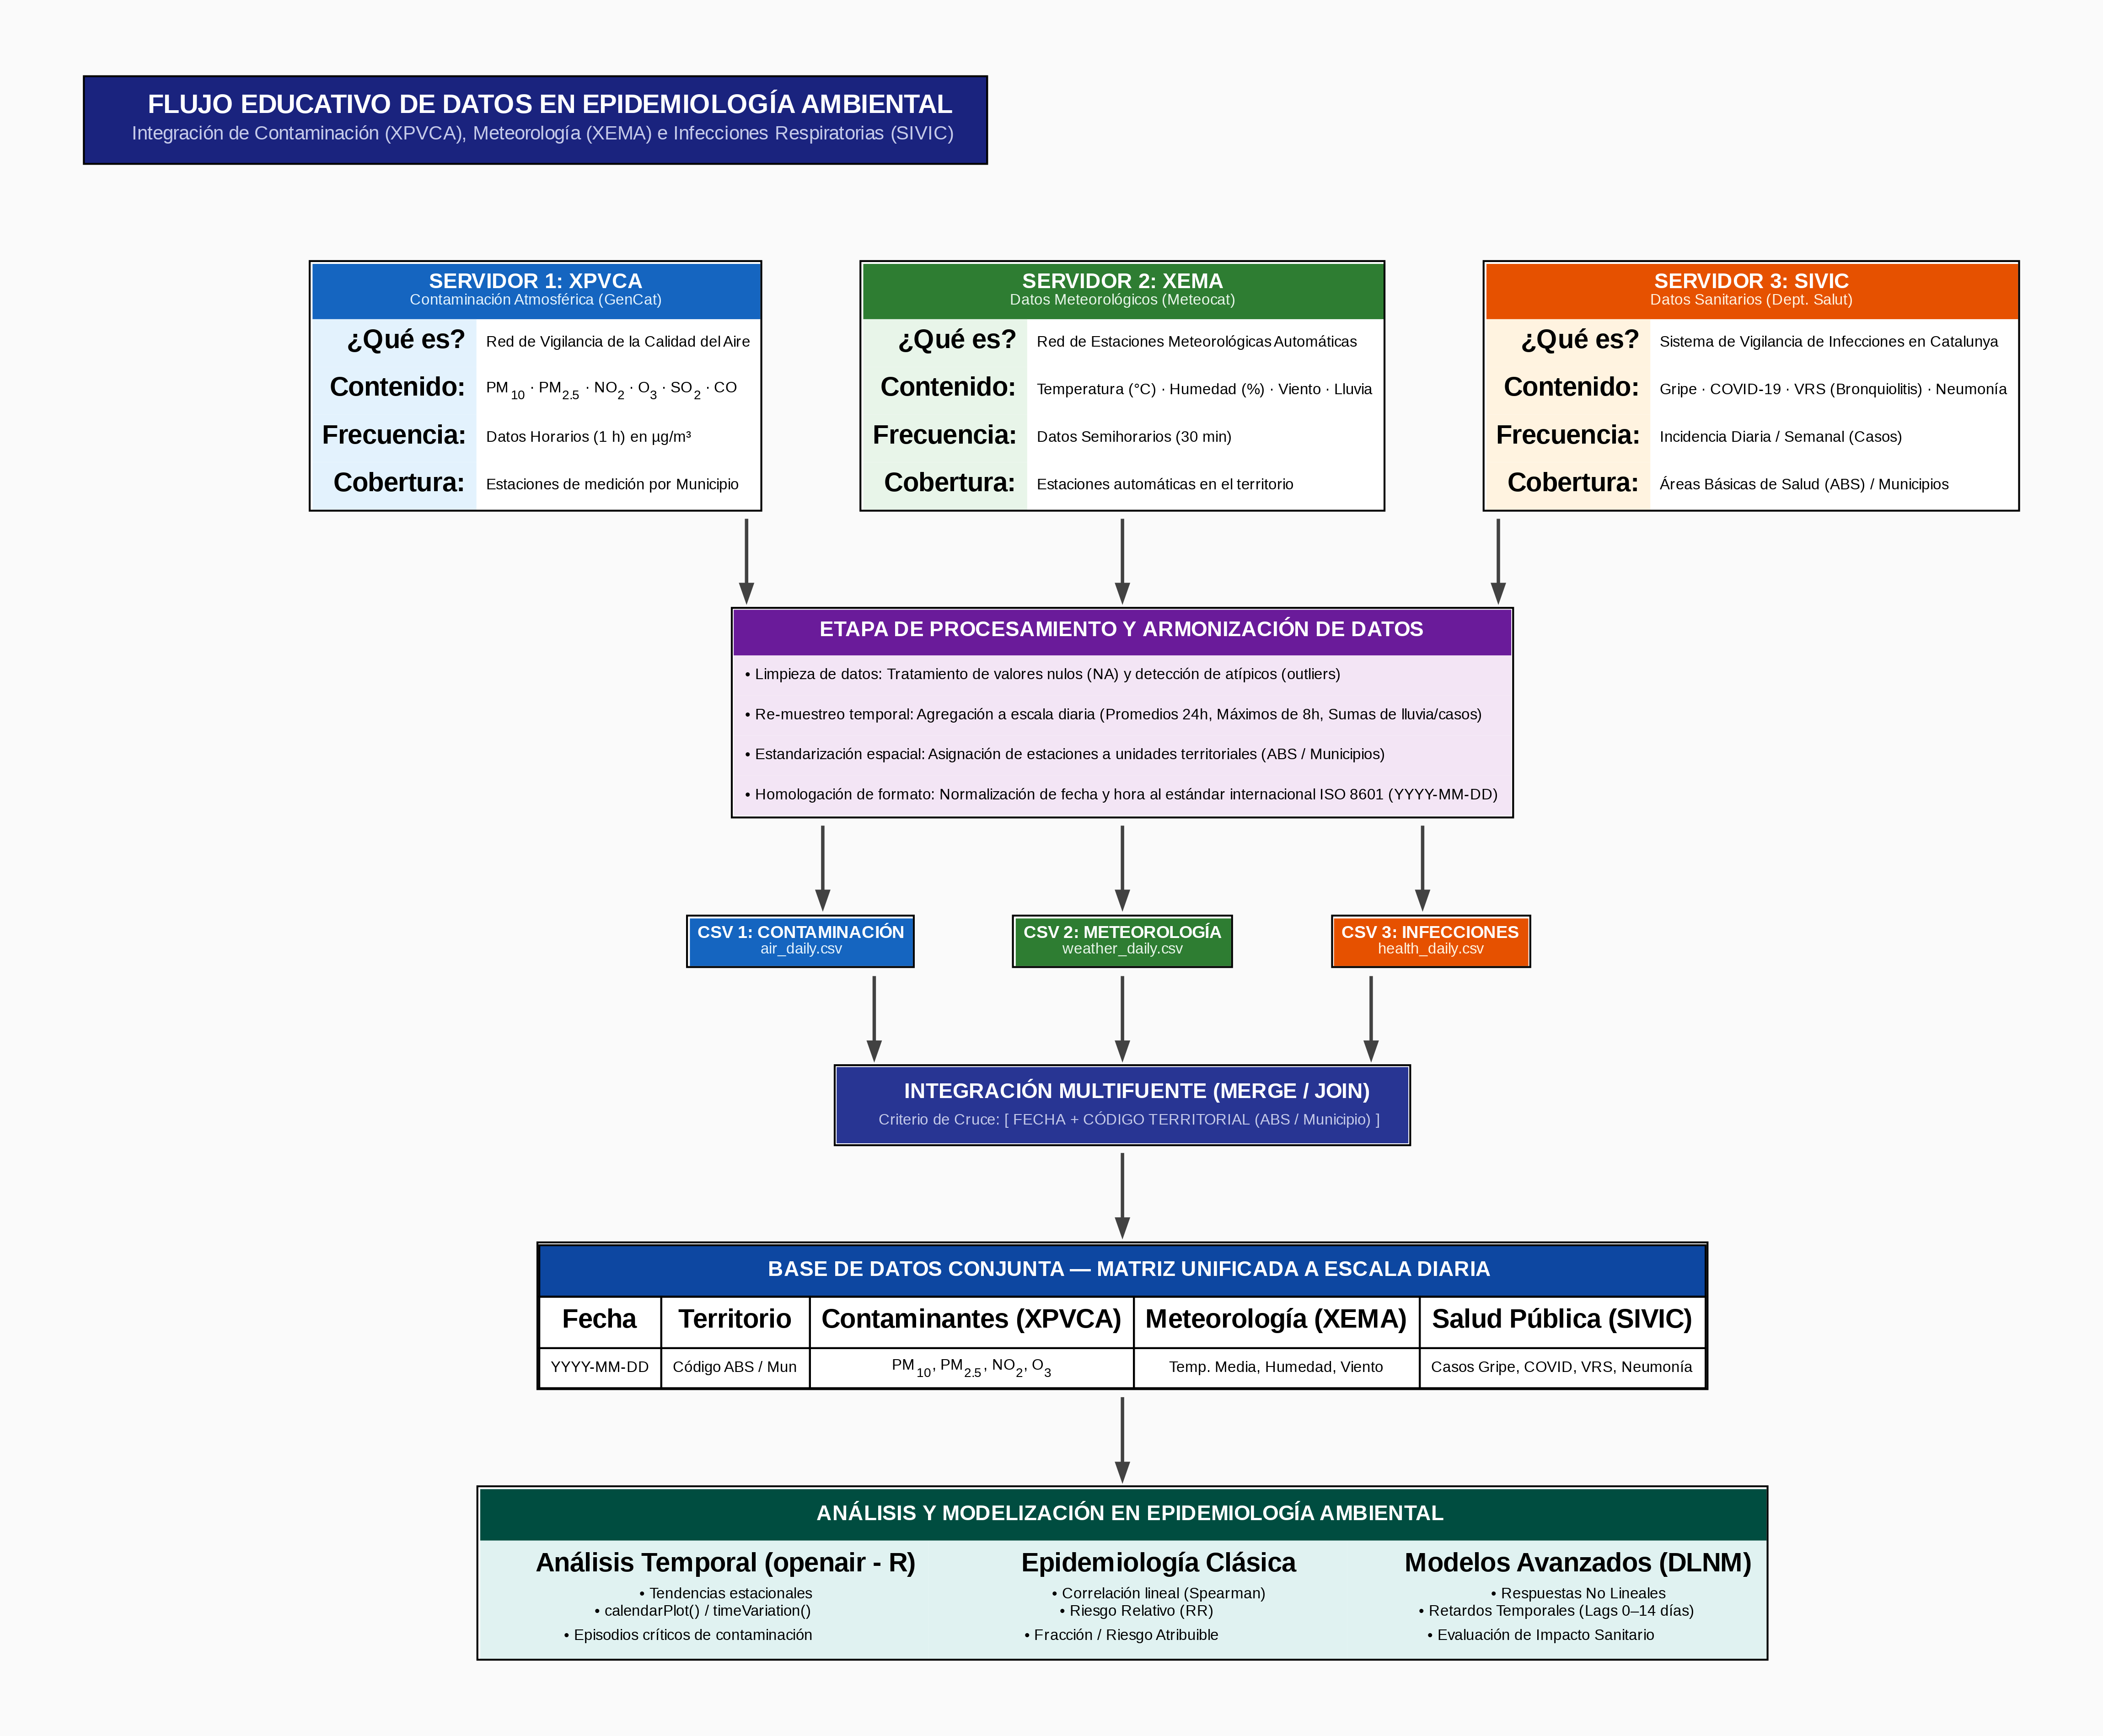

In [1]:
# ============================================================
# DIAGRAMA EDUCATIVO INTEGRADO — EPIDEMIOLOGÍA AMBIENTAL
# BASES DE DATOS: XPVCA (Contaminación), XEMA (Meteocat), SIVIC (Salud)
# UN SOLO ARCHIVO PNG EN ALTA RESOLUCIÓN (300 DPI)
# ============================================================

!apt-get -qq install graphviz -y
!pip install -q graphviz

from graphviz import Digraph
from IPython.display import display, Image

# 1. CREACIÓN Y CONFIGURACIÓN DEL DIAGRAMA
dot = Digraph("flujo_epidemiologia_didactico", format="png")

dot.attr(
    rankdir="TB",
    bgcolor="#FAFAFA",
    pad="0.5",
    nodesep="0.5",
    ranksep="0.6",
    splines="ortho",
    dpi="300"  # Calidad de imprenta / 300 DPI
)

# Estilo global de nodos mediante tablas HTML
dot.attr("node", shape="plaintext", fontname="Arial")

# Estilo global de flechas
dot.attr(
    "edge",
    color="#424242",
    penwidth="1.8",
    arrowsize="0.8",
    fontname="Arial",
    fontsize="9"
)

# ============================================================
# TÍTULO DEL FLUJO
# ============================================================
header_html = '''<
<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0" CELLPADDING="8" BGCOLOR="#1A237E">
  <TR><TD ALIGN="CENTER">
    <FONT COLOR="#FFFFFF" POINT-SIZE="14"><B>FLUJO EDUCATIVO DE DATOS EN EPIDEMIOLOGÍA AMBIENTAL</B></FONT><BR/>
    <FONT COLOR="#C5CAE9" POINT-SIZE="10">Integración de Contaminación (XPVCA), Meteorología (XEMA) e Infecciones Respiratorias (SIVIC)</FONT>
  </TD></TR>
</TABLE>
>'''
dot.node("header", header_html)

# ============================================================
# 1. SERVIDORES DE DATOS (NIVEL SUPERIOR PARALELO)
# ============================================================

# SERVIDOR 1: XPVCA (Contaminación)
xpvca_html = '''<
<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0" CELLPADDING="5" BGCOLOR="#FFFFFF">
  <TR><TD BGCOLOR="#1565C0" COLSPAN="2" ALIGN="CENTER"><FONT COLOR="#FFFFFF" POINT-SIZE="11"><B>SERVIDOR 1: XPVCA</B></FONT><BR/><FONT COLOR="#E3F2FD" POINT-SIZE="8.5">Contaminación Atmosférica (GenCat)</FONT></TD></TR>
  <TR><TD BGCOLOR="#E3F2FD" ALIGN="RIGHT"><B>¿Qué es?</B></TD><TD ALIGN="LEFT"><FONT POINT-SIZE="8.5">Red de Vigilancia de la Calidad del Aire</FONT></TD></TR>
  <TR><TD BGCOLOR="#E3F2FD" ALIGN="RIGHT"><B>Contenido:</B></TD><TD ALIGN="LEFT"><FONT POINT-SIZE="8.5">PM<sub>10</sub> · PM<sub>2.5</sub> · NO<sub>2</sub> · O<sub>3</sub> · SO<sub>2</sub> · CO</FONT></TD></TR>
  <TR><TD BGCOLOR="#E3F2FD" ALIGN="RIGHT"><B>Frecuencia:</B></TD><TD ALIGN="LEFT"><FONT POINT-SIZE="8.5">Datos Horarios (1 h) en µg/m³</FONT></TD></TR>
  <TR><TD BGCOLOR="#E3F2FD" ALIGN="RIGHT"><B>Cobertura:</B></TD><TD ALIGN="LEFT"><FONT POINT-SIZE="8.5">Estaciones de medición por Municipio</FONT></TD></TR>
</TABLE>
>'''

# SERVIDOR 2: XEMA (Meteocat)
xema_html = '''<
<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0" CELLPADDING="5" BGCOLOR="#FFFFFF">
  <TR><TD BGCOLOR="#2E7D32" COLSPAN="2" ALIGN="CENTER"><FONT COLOR="#FFFFFF" POINT-SIZE="11"><B>SERVIDOR 2: XEMA</B></FONT><BR/><FONT COLOR="#E8F5E9" POINT-SIZE="8.5">Datos Meteorológicos (Meteocat)</FONT></TD></TR>
  <TR><TD BGCOLOR="#E8F5E9" ALIGN="RIGHT"><B>¿Qué es?</B></TD><TD ALIGN="LEFT"><FONT POINT-SIZE="8.5">Red de Estaciones Meteorológicas Automáticas</FONT></TD></TR>
  <TR><TD BGCOLOR="#E8F5E9" ALIGN="RIGHT"><B>Contenido:</B></TD><TD ALIGN="LEFT"><FONT POINT-SIZE="8.5">Temperatura (°C) · Humedad (%) · Viento · Lluvia</FONT></TD></TR>
  <TR><TD BGCOLOR="#E8F5E9" ALIGN="RIGHT"><B>Frecuencia:</B></TD><TD ALIGN="LEFT"><FONT POINT-SIZE="8.5">Datos Semihorarios (30 min)</FONT></TD></TR>
  <TR><TD BGCOLOR="#E8F5E9" ALIGN="RIGHT"><B>Cobertura:</B></TD><TD ALIGN="LEFT"><FONT POINT-SIZE="8.5">Estaciones automáticas en el territorio</FONT></TD></TR>
</TABLE>
>'''

# SERVIDOR 3: SIVIC (Salud)
sivic_html = '''<
<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0" CELLPADDING="5" BGCOLOR="#FFFFFF">
  <TR><TD BGCOLOR="#E65100" COLSPAN="2" ALIGN="CENTER"><FONT COLOR="#FFFFFF" POINT-SIZE="11"><B>SERVIDOR 3: SIVIC</B></FONT><BR/><FONT COLOR="#FFF3E0" POINT-SIZE="8.5">Datos Sanitarios (Dept. Salut)</FONT></TD></TR>
  <TR><TD BGCOLOR="#FFF3E0" ALIGN="RIGHT"><B>¿Qué es?</B></TD><TD ALIGN="LEFT"><FONT POINT-SIZE="8.5">Sistema de Vigilancia de Infecciones en Catalunya</FONT></TD></TR>
  <TR><TD BGCOLOR="#FFF3E0" ALIGN="RIGHT"><B>Contenido:</B></TD><TD ALIGN="LEFT"><FONT POINT-SIZE="8.5">Gripe · COVID-19 · VRS (Bronquiolitis) · Neumonía</FONT></TD></TR>
  <TR><TD BGCOLOR="#FFF3E0" ALIGN="RIGHT"><B>Frecuencia:</B></TD><TD ALIGN="LEFT"><FONT POINT-SIZE="8.5">Incidencia Diaria / Semanal (Casos)</FONT></TD></TR>
  <TR><TD BGCOLOR="#FFF3E0" ALIGN="RIGHT"><B>Cobertura:</B></TD><TD ALIGN="LEFT"><FONT POINT-SIZE="8.5">Áreas Básicas de Salud (ABS) / Municipios</FONT></TD></TR>
</TABLE>
>'''

with dot.subgraph() as s:
    s.attr(rank="same")
    s.node("xpvca", xpvca_html)
    s.node("xema", xema_html)
    s.node("sivic", sivic_html)

# ============================================================
# 2. PROCESAMIENTO Y ARMONIZACIÓN
# ============================================================
procesamiento_html = '''<
<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0" CELLPADDING="6" BGCOLOR="#FFFFFF">
  <TR><TD BGCOLOR="#6A1B9A" COLSPAN="2" ALIGN="CENTER"><FONT COLOR="#FFFFFF" POINT-SIZE="11"><B>ETAPA DE PROCESAMIENTO Y ARMONIZACIÓN DE DATOS</B></FONT></TD></TR>
  <TR><TD BGCOLOR="#F3E5F5" ALIGN="LEFT"><FONT POINT-SIZE="8.5">• Limpieza de datos: Tratamiento de valores nulos (NA) y detección de atípicos (outliers)</FONT></TD></TR>
  <TR><TD BGCOLOR="#F3E5F5" ALIGN="LEFT"><FONT POINT-SIZE="8.5">• Re-muestreo temporal: Agregación a escala diaria (Promedios 24h, Máximos de 8h, Sumas de lluvia/casos)</FONT></TD></TR>
  <TR><TD BGCOLOR="#F3E5F5" ALIGN="LEFT"><FONT POINT-SIZE="8.5">• Estandarización espacial: Asignación de estaciones a unidades territoriales (ABS / Municipios)</FONT></TD></TR>
  <TR><TD BGCOLOR="#F3E5F5" ALIGN="LEFT"><FONT POINT-SIZE="8.5">• Homologación de formato: Normalización de fecha y hora al estándar internacional ISO 8601 (YYYY-MM-DD)</FONT></TD></TR>
</TABLE>
>'''
dot.node("procesamiento", procesamiento_html)

# ============================================================
# 3. ARCHIVOS ARCHIVOS INTERMEDIOS (CSV)
# ============================================================
csv_air_html = '''<
<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0" CELLPADDING="4" BGCOLOR="#FFFFFF">
  <TR><TD BGCOLOR="#1565C0" ALIGN="CENTER"><FONT COLOR="#FFFFFF" POINT-SIZE="9.5"><B>CSV 1: CONTAMINACIÓN</B></FONT><BR/><FONT COLOR="#E3F2FD" POINT-SIZE="8">air_daily.csv</FONT></TD></TR>
</TABLE>>'''

csv_weather_html = '''<
<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0" CELLPADDING="4" BGCOLOR="#FFFFFF">
  <TR><TD BGCOLOR="#2E7D32" ALIGN="CENTER"><FONT COLOR="#FFFFFF" POINT-SIZE="9.5"><B>CSV 2: METEOROLOGÍA</B></FONT><BR/><FONT COLOR="#E8F5E9" POINT-SIZE="8">weather_daily.csv</FONT></TD></TR>
</TABLE>>'''

csv_health_html = '''<
<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0" CELLPADDING="4" BGCOLOR="#FFFFFF">
  <TR><TD BGCOLOR="#E65100" ALIGN="CENTER"><FONT COLOR="#FFFFFF" POINT-SIZE="9.5"><B>CSV 3: INFECCIONES</B></FONT><BR/><FONT COLOR="#FFF3E0" POINT-SIZE="8">health_daily.csv</FONT></TD></TR>
</TABLE>>'''

with dot.subgraph() as s:
    s.attr(rank="same")
    s.node("csv_air", csv_air_html)
    s.node("csv_weather", csv_weather_html)
    s.node("csv_health", csv_health_html)

# ============================================================
# 4. INTEGRACIÓN MULTIFUENTE (MERGE / JOIN)
# ============================================================
merge_html = '''<
<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0" CELLPADDING="6" BGCOLOR="#FFFFFF">
  <TR><TD BGCOLOR="#283593" ALIGN="CENTER">
    <FONT COLOR="#FFFFFF" POINT-SIZE="11"><B>INTEGRACIÓN MULTIFUENTE (MERGE / JOIN)</B></FONT><BR/>
    <FONT COLOR="#C5CAE9" POINT-SIZE="8.5">Criterio de Cruce: [ FECHA + CÓDIGO TERRITORIAL (ABS / Municipio) ]</FONT>
  </TD></TR>
</TABLE>
>'''
dot.node("merge", merge_html)

# ============================================================
# 5. BASE DE DATOS CONJUNTA (ESQUEMA DIDÁCTICO)
# ============================================================
daily_db_html = '''<
<TABLE BORDER="1" CELLBORDER="1" CELLSPACING="0" CELLPADDING="5" BGCOLOR="#FFFFFF">
  <TR><TD BGCOLOR="#0D47A1" COLSPAN="5" ALIGN="CENTER">
    <FONT COLOR="#FFFFFF" POINT-SIZE="11"><B>BASE DE DATOS CONJUNTA — MATRIZ UNIFICADA A ESCALA DIARIA</B></FONT>
  </TD></TR>
  <TR BGCOLOR="#C5CAE9">
    <TD ALIGN="CENTER"><B>Fecha</B></TD>
    <TD ALIGN="CENTER"><B>Territorio</B></TD>
    <TD ALIGN="CENTER"><B>Contaminantes (XPVCA)</B></TD>
    <TD ALIGN="CENTER"><B>Meteorología (XEMA)</B></TD>
    <TD ALIGN="CENTER"><B>Salud Pública (SIVIC)</B></TD>
  </TR>
  <TR>
    <TD ALIGN="CENTER"><FONT POINT-SIZE="8">YYYY-MM-DD</FONT></TD>
    <TD ALIGN="CENTER"><FONT POINT-SIZE="8">Código ABS / Mun</FONT></TD>
    <TD ALIGN="CENTER"><FONT POINT-SIZE="8">PM<sub>10</sub>, PM<sub>2.5</sub>, NO<sub>2</sub>, O<sub>3</sub></FONT></TD>
    <TD ALIGN="CENTER"><FONT POINT-SIZE="8">Temp. Media, Humedad, Viento</FONT></TD>
    <TD ALIGN="CENTER"><FONT POINT-SIZE="8">Casos Gripe, COVID, VRS, Neumonía</FONT></TD>
  </TR>
</TABLE>
>'''
dot.node("daily", daily_db_html)

# ============================================================
# 6. APLICACIONES Y MODELIZACIÓN EPIDEMIOLÓGICA
# ============================================================
apps_html = '''<
<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0" CELLPADDING="6" BGCOLOR="#FFFFFF">
  <TR><TD BGCOLOR="#004D40" COLSPAN="3" ALIGN="CENTER">
    <FONT COLOR="#FFFFFF" POINT-SIZE="11"><B>ANÁLISIS Y MODELIZACIÓN EN EPIDEMIOLOGÍA AMBIENTAL</B></FONT>
  </TD></TR>
  <TR>
    <TD BGCOLOR="#E0F2F1" ALIGN="CENTER" WIDTH="220">
      <B>Análisis Temporal (openair - R)</B><BR/>
      <FONT POINT-SIZE="8">• Tendencias estacionales<BR/>• calendarPlot() / timeVariation()<BR/>• Episodios críticos de contaminación</FONT>
    </TD>
    <TD BGCOLOR="#E0F2F1" ALIGN="CENTER" WIDTH="220">
      <B>Epidemiología Clásica</B><BR/>
      <FONT POINT-SIZE="8">• Correlación lineal (Spearman)<BR/>• Riesgo Relativo (RR)<BR/>• Fracción / Riesgo Atribuible</FONT>
    </TD>
    <TD BGCOLOR="#E0F2F1" ALIGN="CENTER" WIDTH="220">
      <B>Modelos Avanzados (DLNM)</B><BR/>
      <FONT POINT-SIZE="8">• Respuestas No Lineales<BR/>• Retardos Temporales (Lags 0–14 días)<BR/>• Evaluación de Impacto Sanitario</FONT>
    </TD>
  </TR>
</TABLE>
>'''
dot.node("apps", apps_html)

# ============================================================
# CONEXIONES Y FLUJO DE DATOS
# ============================================================
dot.edge("header", "xpvca", style="invis") # Espaciado inicial

# Servidores -> Procesamiento
dot.edge("xpvca", "procesamiento")
dot.edge("xema", "procesamiento", weight="3") # Eje central vertical
dot.edge("sivic", "procesamiento")

# Procesamiento -> CSVs intermedios
dot.edge("procesamiento", "csv_air")
dot.edge("procesamiento", "csv_weather", weight="3")
dot.edge("procesamiento", "csv_health")

# CSVs -> Integración
dot.edge("csv_air", "merge")
dot.edge("csv_weather", "merge", weight="3")
dot.edge("csv_health", "merge")

# Integración -> Base de Datos Conjunta -> Análisis
dot.edge("merge", "daily", weight="3")
dot.edge("daily", "apps", weight="3")

# ============================================================
# RENDERIZADO Y EXPORTACIÓN EN COLAB
# ============================================================
dot.render("/content/flujo_epidemiologia_ambiental_didactico", cleanup=True)

print("Diagrama generado exitosamente en resolución de imprenta (300 DPI):")
print("/content/flujo_epidemiologia_ambiental_didactico.png\n")

# Mostrar en la libreta de Colab
display(Image("/content/flujo_epidemiologia_ambiental_didactico.png"))

In [4]:

from IPython.display import HTML

html_content = """<!DOCTYPE html>
<html lang="ca">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Fluix de Treball Interactiu — Epidemiologia Ambiental</title>
    <style>
        :root {
            --primary-bg: #f8fafc;
            --card-bg: #ffffff;
            --text-main: #0f172a;
            --text-muted: #475569;
            --border-color: #e2e8f0;

            --xpvca-color: #0284c7;
            --xpvca-bg: #f0f9ff;
            --xema-color: #16a34a;
            --xema-bg: #f0fdf4;
            --sivic-color: #ea580c;
            --sivic-bg: #fff7ed;
            --process-color: #9333ea;
            --process-bg: #faf5ff;
            --db-color: #1d4ed8;
            --db-bg: #eff6ff;
            --analysis-color: #0d9488;
            --analysis-bg: #f0fdfa;
        }

        * {
            box-sizing: border-box;
            margin: 0;
            padding: 0;
            font-family: system-ui, -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;
        }

        body {
            background-color: var(--primary-bg);
            color: var(--text-main);
            padding: 2rem 1rem;
            min-height: 100vh;
        }

        .container {
            max-width: 1100px;
            margin: 0 auto;
        }

        header {
            text-align: center;
            margin-bottom: 2rem;
        }

        header h1 {
            font-size: 2.2rem;
            color: #1e293b;
            margin-bottom: 0.5rem;
            font-weight: 800;
        }

        header p {
            font-size: 1.1rem;
            color: var(--text-muted);
        }

        .instruction-banner {
            background-color: #e0f2fe;
            border: 1px solid #bae6fd;
            color: #0369a1;
            padding: 0.75rem 1.25rem;
            border-radius: 8px;
            text-align: center;
            font-weight: 600;
            font-size: 0.95rem;
            margin-bottom: 2rem;
        }

        .flow-section {
            display: flex;
            flex-direction: column;
            gap: 1.5rem;
            align-items: center;
        }

        .servers-row {
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(300px, 1fr));
            gap: 1.5rem;
            width: 100%;
        }

        .arrow-down {
            text-align: center;
            font-size: 1.8rem;
            color: #94a3b8;
            margin: -0.5rem 0;
        }

        .card {
            background-color: var(--card-bg);
            border-radius: 12px;
            border: 2px solid var(--border-color);
            padding: 1.5rem;
            cursor: pointer;
            transition: all 0.25s ease-in-out;
            box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.05);
            position: relative;
        }

        .card:hover {
            transform: translateY(-4px);
            box-shadow: 0 12px 20px -5px rgba(0, 0, 0, 0.12);
            border-color: #94a3b8;
        }

        .card::after {
            content: "🔍 Clica per ampliar";
            position: absolute;
            bottom: 0.8rem;
            right: 1rem;
            font-size: 0.75rem;
            font-weight: 600;
            color: var(--text-muted);
            opacity: 0.75;
        }

        .card-tag {
            display: inline-block;
            padding: 0.25rem 0.6rem;
            border-radius: 6px;
            font-size: 0.75rem;
            font-weight: 700;
            text-transform: uppercase;
            margin-bottom: 0.75rem;
        }

        .card h3 {
            font-size: 1.25rem;
            margin-bottom: 0.5rem;
        }

        .card p {
            font-size: 0.95rem;
            color: var(--text-muted);
            line-height: 1.5;
            margin-bottom: 1rem;
        }

        .card-stats {
            display: flex;
            gap: 0.5rem;
            flex-wrap: wrap;
            margin-bottom: 0.5rem;
        }

        .stat-pill {
            background-color: #f1f5f9;
            padding: 0.2rem 0.5rem;
            border-radius: 4px;
            font-size: 0.8rem;
            font-weight: 600;
            color: #334155;
        }

        .card-xpvca { border-top: 6px solid var(--xpvca-color); }
        .card-xpvca .card-tag { background-color: var(--xpvca-bg); color: var(--xpvca-color); }

        .card-xema { border-top: 6px solid var(--xema-color); }
        .card-xema .card-tag { background-color: var(--xema-bg); color: var(--xema-color); }

        .card-sivic { border-top: 6px solid var(--sivic-color); }
        .card-sivic .card-tag { background-color: var(--sivic-bg); color: var(--sivic-color); }

        .card-process { border-top: 6px solid var(--process-color); width: 100%; }
        .card-process .card-tag { background-color: var(--process-bg); color: var(--process-color); }

        .card-db { border-top: 6px solid var(--db-color); width: 100%; }
        .card-db .card-tag { background-color: var(--db-bg); color: var(--db-color); }

        .card-analysis { border-top: 6px solid var(--analysis-color); width: 100%; }
        .card-analysis .card-tag { background-color: var(--analysis-bg); color: var(--analysis-color); }

        .modal-overlay {
            position: fixed;
            top: 0; left: 0; width: 100%; height: 100%;
            background-color: rgba(15, 23, 42, 0.7);
            backdrop-filter: blur(5px);
            display: flex; justify-content: center; align-items: center;
            opacity: 0; visibility: hidden;
            transition: all 0.3s ease;
            z-index: 1000; padding: 1.5rem;
        }

        .modal-overlay.active { opacity: 1; visibility: visible; }

        .modal-container {
            background-color: #ffffff;
            border-radius: 16px;
            max-width: 800px; width: 100%;
            max-height: 90vh; overflow-y: auto;
            padding: 2rem; position: relative;
            transform: scale(0.9); transition: transform 0.3s ease;
            box-shadow: 0 25px 50px -12px rgba(0, 0, 0, 0.25);
        }

        .modal-overlay.active .modal-container { transform: scale(1); }

        .close-btn {
            position: absolute; top: 1.25rem; right: 1.25rem;
            background: #f1f5f9; border: none;
            width: 36px; height: 36px; border-radius: 50%;
            font-size: 1.2rem; cursor: pointer;
            display: flex; align-items: center; justify-content: center;
            color: #64748b;
        }

        .close-btn:hover { background: #e2e8f0; color: #0f172a; }

        .modal-header h2 { font-size: 1.8rem; color: #0f172a; margin-top: 0.5rem; }
        .modal-section { margin-top: 1.25rem; }
        .modal-section h4 { font-size: 1.1rem; color: #1e293b; border-bottom: 2px solid #f1f5f9; padding-bottom: 0.3rem; margin-bottom: 0.5rem; }

        .modal-list { list-style: none; padding-left: 0; }
        .modal-list li { position: relative; padding-left: 1.25rem; margin-bottom: 0.5rem; }
        .modal-list li::before { content: "•"; position: absolute; left: 0.3rem; color: #0284c7; font-weight: bold; }

        .data-table { width: 100%; border-collapse: collapse; margin-top: 0.75rem; font-size: 0.9rem; }
        .data-table th, .data-table td { border: 1px solid #e2e8f0; padding: 0.6rem 0.8rem; text-align: left; }
        .data-table th { background-color: #f8fafc; font-weight: 700; }
        .key-hint { font-size: 0.8rem; color: #94a3b8; text-align: center; margin-top: 1.5rem; }
    </style>
</head>
<body>

    <div class="container">
        <header>
            <h1>Epidemiologia Ambiental a Catalunya</h1>
            <p>Fluix d'Integració i Anàlisi de Dades Multifont</p>
        </header>

        <div class="instruction-banner">
            💡 <strong>Modi Presentació Interactiva:</strong> Clica sobre qualsevol recadre per ampliar les especificacions tècniques i detalls de la base de dades.
        </div>

        <div class="flow-section">

            <div class="servers-row">
                <!-- CARD 1: XPVCA -->
                <div class="card card-xpvca" onclick="openModal('xpvca')">
                    <span class="card-tag">Servidor 1 — GenCat</span>
                    <h3>XPVCA</h3>
                    <p>Xarxa de Vigilància i Previsió de la Contaminació Atmosfèrica</p>
                    <div class="card-stats">
                        <span class="stat-pill">PM₁₀ · PM₂.₅</span>
                        <span class="stat-pill">NO₂ · O₃</span>
                        <span class="stat-pill">Dades Horàries</span>
                    </div>
                </div>

                <!-- CARD 2: XEMA -->
                <div class="card card-xema" onclick="openModal('xema')">
                    <span class="card-tag">Servidor 2 — Meteocat</span>
                    <h3>XEMA</h3>
                    <p>Xarxa d'Estacions Meteorològiques Automàtiques</p>
                    <div class="card-stats">
                        <span class="stat-pill">Temperatura</span>
                        <span class="stat-pill">Humitat · Vent</span>
                        <span class="stat-pill">Semihorari (30 min)</span>
                    </div>
                </div>

                <!-- CARD 3: SIVIC -->
                <div class="card card-sivic" onclick="openModal('sivic')">
                    <span class="card-tag">Servidor 3 — Dept. Salut</span>
                    <h3>SIVIC</h3>
                    <p>Sistema d'Informació per a la Vigilància d'Infeccions a Catalunya</p>
                    <div class="card-stats">
                        <span class="stat-pill">Grip · COVID-19</span>
                        <span class="stat-pill">VRS · Pneumònia</span>
                        <span class="stat-pill">Incidència Diària</span>
                    </div>
                </div>
            </div>

            <div class="arrow-down">⬇️</div>

            <!-- CARD 4: PROCESSAMENT -->
            <div class="card card-process" onclick="openModal('process')">
                <span class="card-tag">Enginyeria de Dades</span>
                <h3>Processament, Neteja i Harmonització</h3>
                <p>Tractament de valors nuls, re-mostreig temporal a escala diària, estandardització de codis territorials (ABS/Municipi) i format temporal ISO 8601.</p>
            </div>

            <div class="arrow-down">⬇️</div>

            <!-- CARD 5: BASE DE DADES CONJUNTA -->
            <div class="card card-db" onclick="openModal('db')">
                <span class="card-tag">Matriu Unificada</span>
                <h3>Base de Dades Conjunta — Escala Diària</h3>
                <p>Cruce multifont (Merge / Join) relacionat per data i àrea territorial. Matriu unificada llista per a modelització estadística.</p>
            </div>

            <div class="arrow-down">⬇️</div>

            <!-- CARD 6: ANÀLISI I MODELITZACIÓ -->
            <div class="card card-analysis" onclick="openModal('analysis')">
                <span class="card-tag">Anàlisi Científica</span>
                <h3>Modelització Epidemiològica i DLNM</h3>
                <p>Avaluació de patrons temporals amb <code>openair</code>, càlcul de Riscos Relatius (RR) i Models No Lineals de Retard Distribuït (DLNM) per a efectes acumulats (lags 0–14 dies).</p>
            </div>

        </div>
    </div>

    <!-- MODAL POPUP -->
    <div class="modal-overlay" id="modalOverlay" onclick="closeModalOnBackdrop(event)">
        <div class="modal-container">
            <button class="close-btn" onclick="closeModal()">&times;</button>
            <div id="modalHeader"></div>
            <div id="modalBody"></div>
            <div class="key-hint">Prem <code>ESC</code> o clica fora de la finestra per tancar</div>
        </div>
    </div>

    <script>
        const modalData = {
            xpvca: {
                tag: "SERVIDOR 1 — GENCAT", tagBg: "#f0f9ff", tagColor: "#0284c7",
                title: "XPVCA — Contaminació Atmosfèrica",
                content: `
                    <div class="modal-section">
                        <h4>Què és la XPVCA?</h4>
                        <p>La <strong>Xarxa de Vigilància i Previsió de la Contaminació Atmosfèrica</strong> és el sistema oficial de la Generalitat de Catalunya encarregat de mesurar la qualitat de l'aire mitjançant estacions de mesura automàtiques i manuals distribuïdes per tot el territori.</p>
                    </div>
                    <div class="modal-section">
                        <h4>Variables i Mesuraments Principals</h4>
                        <ul class="modal-list">
                            <li><strong>Partícules en suspensió (PM₁₀ i PM₂.₅):</strong> Indicadors clau d'infeccions respiratòries profundes.</li>
                            <li><strong>Dióxid de Nitrogen (NO₂):</strong> Associat al trànsit rodat i cremat de combustibles.</li>
                            <li><strong>Ozó Troposfèric (O₃):</strong> Contaminant secundari d'estiu amb alt poder oxidant.</li>
                            <li><strong>Dióxid de Sofre (SO₂) i Monòxid de Carboni (CO):</strong> Emissions industrials i combustions incomplets.</li>
                        </ul>
                    </div>
                    <div class="modal-section">
                        <h4>Especificacions Tècniques</h4>
                        <table class="data-table">
                            <tr><th>Resolució Temporal</th><td>Registres horaris (1 hora)</td></tr>
                            <tr><th>Unitats de Mesura</th><td>Micrograms per metre cúbic (µg/m³)</td></tr>
                            <tr><th>Cobertura Geogràfica</th><td>Estacions assignades per Codi de Municipi i Comarca</td></tr>
                        </table>
                    </div>
                `
            },
            xema: {
                tag: "SERVIDOR 2 — METEOCAT", tagBg: "#f0fdf4", tagColor: "#16a34a",
                title: "XEMA — Dades Meteorològiques",
                content: `
                    <div class="modal-section">
                        <h4>Què és la XEMA?</h4>
                        <p>La <strong>Xarxa d'Estacions Meteorològiques Automàtiques</strong> gestionada per Meteocat monitora contínuament les condicions atmosfèriques a temps real.</p>
                    </div>
                    <div class="modal-section">
                        <h4>Variables Climàtiques Clau</h4>
                        <ul class="modal-list">
                            <li><strong>Temperatura (°C):</strong> Variable de confusió fonamental en epidemiologia (onades de fred/calor).</li>
                            <li><strong>Humitat Relativa (%):</strong> Afecta la persistència i viabilitat dels aerosols virals en l'aire.</li>
                            <li><strong>Velocitat del Vent (m/s):</strong> Determina la dispersió o acumulació local dels contaminants.</li>
                            <li><strong>Precipitació Acumulada (mm):</strong> Efecte de rentat de l'atmosfera (<em>rainout</em>).</li>
                        </ul>
                    </div>
                    <div class="modal-section">
                        <h4>Especificacions Tècniques</h4>
                        <table class="data-table">
                            <tr><th>Resolució Temporal</th><td>Dades semihoràries (cada 30 minuts)</td></tr>
                            <tr><th>Infraestructura</th><td>Més de 180 estacions automàtiques equipades amb sensors homologats</td></tr>
                        </table>
                    </div>
                `
            },
            sivic: {
                tag: "SERVIDOR 3 — DEPT. SALUT", tagBg: "#fff7ed", tagColor: "#ea580c",
                title: "SIVIC — Vigilància d'Infeccions Sanitàries",
                content: `
                    <div class="modal-section">
                        <h4>Què és el SIVIC?</h4>
                        <p>El <strong>Sistema d'Informació per a la Vigilància d'Infeccions a Catalunya</strong> integra la vigilància epidemiològica de les Infeccions Respiratòries Agudes (IRA) tant en atenció primària com hospitalària.</p>
                    </div>
                    <div class="modal-section">
                        <h4>Indicadors Sanitaris Monitorats</h4>
                        <ul class="modal-list">
                            <li><strong>Grip (Virus Influenza):</strong> Diagnòstics clínics i confirmacions microbiològiques.</li>
                            <li><strong>COVID-19 (SARS-CoV-2):</strong> Casos notificats i taxa d'incidència acumulada.</li>
                            <li><strong>Virus Respiratori Sincitial (VRS):</strong> Causant principal de bronquiolitis en infantils.</li>
                            <li><strong>Pneumònies Comunitàries:</strong> Registres diagnòstics en Atenció Primària (CAP).</li>
                        </ul>
                    </div>
                    <div class="modal-section">
                        <h4>Especificacions Tècniques</h4>
                        <table class="data-table">
                            <tr><th>Resolució Temporal</th><td>Incidència diària i agrupat setmanal epidemiològic</td></tr>
                            <tr><th>Escala Territorial</th><td>Àrees Bàsiques de Salut (ABS), Regions Sanitàries i Municipis</td></tr>
                        </table>
                    </div>
                `
            },
            process: {
                tag: "ENGINYERIA DE DADES", tagBg: "#faf5ff", tagColor: "#9333ea",
                title: "Processament, Neteja i Harmonització",
                content: `
                    <div class="modal-section">
                        <h4>Passos de l'Harmonització</h4>
                        <ul class="modal-list">
                            <li><strong>Depuració de Nuls i Atípics:</strong> Imputació o filtratge de valors erronis/mancants (NA).</li>
                            <li><strong>Agregació Temporal Diària:</strong>
                                <ul>
                                    <li>Contaminació: Mitjana diària de 24h (PM₁₀, NO₂) o màxim diari de 8h (O₃).</li>
                                    <li>Meteorologia: Mitjana diària de T° i Humitat, suma de precipitació.</li>
                                    <li>Salut: Suma diària de nous casos registrats.</li>
                                </ul>
                            </li>
                            <li><strong>Normalització ISO 8601:</strong> Conversió al format de data unificat <code>YYYY-MM-DD</code>.</li>
                            <li><strong>Enllaç Territorial:</strong> Mapeig espacial entre estacions de mesura i Àrees Bàsiques de Salut (ABS).</li>
                        </ul>
                    </div>
                `
            },
            db: {
                tag: "MATRIU UNIFICADA", tagBg: "#eff6ff", tagColor: "#1d4ed8",
                title: "Base de Dades Conjunta — Escala Diària",
                content: `
                    <div class="modal-section">
                        <h4>Vista Esquematitzada de la Taula</h4>
                        <table class="data-table">
                            <thead>
                                <tr><th>Data</th><th>Territori (ABS)</th><th>PM₁₀ (µg/m³)</th><th>NO₂ (µg/m³)</th><th>Temp (°C)</th><th>Casos Grip</th></tr>
                            </thead>
                            <tbody>
                                <tr><td>2024-01-15</td><td>ABS-001</td><td>32.4</td><td>41.2</td><td>6.8</td><td>14</td></tr>
                                <tr><td>2024-01-16</td><td>ABS-001</td><td>28.1</td><td>38.5</td><td>7.2</td><td>18</td></tr>
                            </tbody>
                        </table>
                    </div>
                `
            },
            analysis: {
                tag: "MODELITZACIÓ AVANÇADA", tagBg: "#f0fdfa", tagColor: "#0d9488",
                title: "Modelització Epidemiològica i DLNM",
                content: `
                    <div class="modal-section">
                        <h4>Anàlisi Exploratòria Temporal (openair)</h4>
                        <p>Ús de funcions com <code>timeVariation()</code> i <code>calendarPlot()</code> per a identificar estacionalitats i episodis de contaminació elevada.</p>
                    </div>
                    <div class="modal-section">
                        <h4>Models DLNM (Distributed Lag Non-Linear Models)</h4>
                        <ul class="modal-list">
                            <li><strong>Efectes Retardats (Lags 0–14 dies):</strong> Avalua l'impacte d'un pic de contaminació al cap de diversos dies.</li>
                            <li><strong>Risc Relatiu (RR):</strong> Quantifica l'increment del risc de delicats sanitaris per increment de contaminació.</li>
                        </ul>
                    </div>
                `
            }
        };

        function openModal(key) {
            const data = modalData[key];
            if (!data) return;
            document.getElementById('modalHeader').innerHTML = `<span class="card-tag" style="background-color: ${data.tagBg}; color: ${data.tagColor};">${data.tag}</span><h2>${data.title}</h2>`;
            document.getElementById('modalBody').innerHTML = data.content;
            document.getElementById('modalOverlay').classList.add('active');
            document.body.style.overflow = 'hidden';
        }

        function closeModal() {
            document.getElementById('modalOverlay').classList.remove('active');
            document.body.style.overflow = 'auto';
        }

        function closeModalOnBackdrop(event) {
            if (event.target.id === 'modalOverlay') closeModal();
        }

        document.addEventListener('keydown', e => { if (e.key === 'Escape') closeModal(); });
    </script>
</body>
</html>
"""

# Mostrar la infografía interactiva en Google Colab
HTML(html_content)

In [8]:
from google.colab import files

# 1. Guardar l'arxiu HTML en el servidor de Colab
with open("flujo_epidemiologia_interactivo.html", "w", encoding="utf-8") as f:
    f.write(html_content)

# 2. Forçar la descàrrega automàtica al teu navegador
files.download("flujo_epidemiologia_interactivo.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
with open("flujo_epidemiologia_interactivo.html", "w", encoding="utf-8") as f:
    f.write(html_content)